In [1]:
import pandas as pd
filename = r'G:\11111111111111111\python\中国人\数据\chinesebmtzxz.csv'
data = pd.read_csv(filename)
display(data)# dataframe

,Age,Primary site,Histological type,T Stage,N Stage,Surgery status,Radiation status,Chemotherapy status,Tumor size,Metastasis
0,3,7,1,3,3,1,0,1,1,0
1,4,6,1,3,0,0,0,0,2,0
2,0,8,2,4,4,0,2,1,2,0
3,3,3,0,2,3,1,0,1,0,0
4,4,8,0,4,0,0,2,1,1,1
...,...,...,...,...,...,...,...,...,...,...
1941,3,3,0,2,0,1,2,1,0,0
1942,0,0,0,2,4,0,2,1,1,0
1943,2,5,0,0,0,1,2,1,0,0
1944,0,2,0,4,0,0,2,1,2,0


In [2]:
y = data['Metastasis']
display(y)
X = data.drop(columns=['Metastasis'])
display(X)

0       0
1       0
2       0
3       0
4       1
       ..
1941    0
1942    0
1943    0
1944    0
1945    1
Name: Metastasis, Length: 1946, dtype: int64

,Age,Primary site,Histological type,T Stage,N Stage,Surgery status,Radiation status,Chemotherapy status,Tumor size
0,3,7,1,3,3,1,0,1,1
1,4,6,1,3,0,0,0,0,2
2,0,8,2,4,4,0,2,1,2
3,3,3,0,2,3,1,0,1,0
4,4,8,0,4,0,0,2,1,1
...,...,...,...,...,...,...,...,...,...
1941,3,3,0,2,0,1,2,1,0
1942,0,0,0,2,4,0,2,1,1
1943,2,5,0,0,0,1,2,1,0
1944,0,2,0,4,0,0,2,1,2


In [3]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from collections import Counter

# 初始化 SMOTE
smote = SMOTE(sampling_strategy='auto', random_state=2024)

# 首先应用 SMOTE
X_smote, y_smote = smote.fit_resample(X, y)

# 然后应用 TomekLinks
tomek = TomekLinks()
X_resampled, y_resampled = tomek.fit_resample(X_smote, y_smote)

# 查看采样后的数据分布
print('Original dataset shape:', Counter(y))
print('After SMOTE shape:', Counter(y_smote))
print('After TomekLinks shape:', Counter(y_resampled))

Original dataset shape: Counter({0: 1619, 1: 327})
After SMOTE shape: Counter({0: 1619, 1: 1619})
After TomekLinks shape: Counter({0: 1619, 1: 1593})


In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.7, random_state=2024)

In [5]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=2024)

In [6]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_validate
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score, f1_score,
    classification_report
)

# =========================
# Step 1. 训练集上调参
# =========================

pipe = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),   # one-hot 稀疏矩阵必需
    ("clf", LogisticRegression(
        solver="saga",
        max_iter=10000,
        random_state=2024
    ))
])

param_grid = {
    "clf__C": [0.001, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10],
    "clf__penalty": ["l1", "l2"],
    "clf__class_weight": [None, "balanced"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=2024)

grid_lr = GridSearchCV(
    pipe,
    param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=1,
    verbose=1
)

grid_lr.fit(X_train, y_train)

print("Best CV AUC:", grid_lr.best_score_)
print("Best params:", grid_lr.best_params_)

best_lr = grid_lr.best_estimator_


# =========================
# Step 2. 用最优 LR 进行统一评估
# =========================

def eval_model(model, X_train, y_train, X_test, y_test, cv=5):
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=2024)
    scoring = {
        "auc":"roc_auc",
        "acc":"accuracy",
        "precision":"precision",
        "recall":"recall",
        "f1":"f1"
    }

    cv_res = cross_validate(model, X_train, y_train, cv=skf, scoring=scoring, n_jobs=1)

    print("\n=== CV Performance (Train, mean ± std) ===")
    for k in scoring:
        print(f"{k}: {cv_res[f'test_{k}'].mean():.4f} ± {cv_res[f'test_{k}'].std():.4f}")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]

    print("\n=== Test Performance ===")
    print("AUC:", roc_auc_score(y_test, y_proba))
    print(classification_report(y_test, y_pred, digits=4))

    return cv_res, y_pred, y_proba


# =========================
# Step 3. 运行
# =========================

eval_model(best_lr, X_train, y_train, X_test, y_test)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best CV AUC: 0.84330145747494
Best params: {'clf__C': 0.05, 'clf__class_weight': None, 'clf__penalty': 'l1'}

=== CV Performance (Train, mean ± std) ===
auc: 0.8433 ± 0.0237
acc: 0.7674 ± 0.0218
precision: 0.6895 ± 0.0224
recall: 0.9323 ± 0.0222
f1: 0.7924 ± 0.0167

=== Test Performance ===
AUC: 0.8384272257768568
              precision    recall  f1-score   support

           0     0.8959    0.5952    0.7152      1114
           1     0.7011    0.9322    0.8003      1135

    accuracy                         0.7652      2249
   macro avg     0.7985    0.7637    0.7578      2249
weighted avg     0.7976    0.7652    0.7582      2249



({'fit_time': array([0.00298381, 0.00316477, 0.00426412, 0.00476193, 0.00395703]),
  'score_time': array([0.00391412, 0.00283027, 0.00399685, 0.00321102, 0.00337815]),
  'test_auc': array([0.84997848, 0.81328024, 0.81774645, 0.87009031, 0.86541182]),
  'test_acc': array([0.79274611, 0.75647668, 0.73056995, 0.77604167, 0.78125   ]),
  'test_precision': array([0.72033898, 0.66917293, 0.65873016, 0.7       , 0.69918699]),
  'test_recall': array([0.92391304, 0.9673913 , 0.90217391, 0.92307692, 0.94505495]),
  'test_f1': array([0.80952381, 0.79111111, 0.76146789, 0.79620853, 0.80373832])},
 array([1, 0, 1, ..., 1, 0, 0], dtype=int64),
 array([0.73441249, 0.08691509, 0.65692684, ..., 0.50470829, 0.0821914 ,
        0.19304091]))

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

res = pd.DataFrame(grid_lr.cv_results_)

# 只留关键列（也方便你导出成表格）
res = res[[
    "param_clf__C",
    "param_clf__penalty",
    "param_clf__class_weight",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].copy()

# 转成更好用的类型
res["param_clf__C"] = res["param_clf__C"].astype(float)
res["param_clf__penalty"] = res["param_clf__penalty"].astype(str)
res["param_clf__class_weight"] = res["param_clf__class_weight"].astype(str)  # None 会变成 "None"


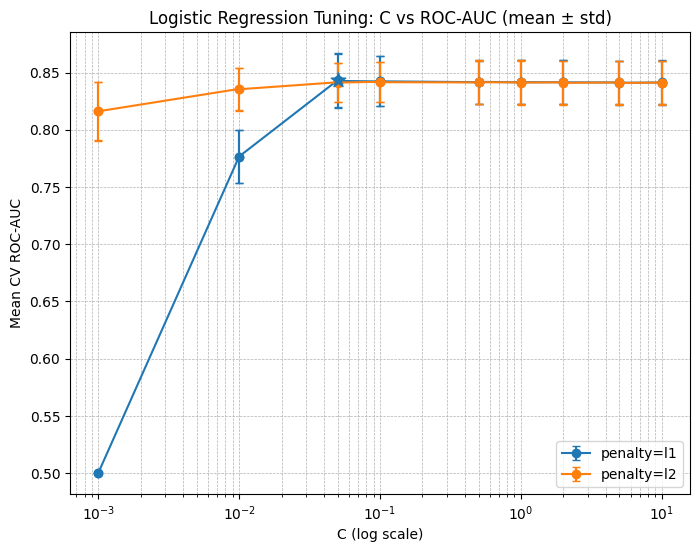

Best shown on plot: {'param_clf__C': 0.05, 'param_clf__penalty': 'l1', 'param_clf__class_weight': 'None', 'mean_test_score': 0.84330145747494, 'std_test_score': 0.02368723214809244, 'rank_test_score': 1}


In [8]:
plt.figure(figsize=(8,6))

for pen in sorted(res["param_clf__penalty"].unique()):
    sub = res[res["param_clf__penalty"] == pen].sort_values("param_clf__C")
    plt.errorbar(
        sub["param_clf__C"],
        sub["mean_test_score"],
        yerr=sub["std_test_score"],
        marker="o",
        capsize=3,
        label=f"penalty={pen}"
    )

# 标出最优点
best_idx = res["mean_test_score"].idxmax()
best_row = res.loc[best_idx]
plt.scatter([best_row["param_clf__C"]], [best_row["mean_test_score"]], s=120, marker="*", zorder=5)

plt.xscale("log")
plt.xlabel("C (log scale)")
plt.ylabel("Mean CV ROC-AUC")
plt.title("Logistic Regression Tuning: C vs ROC-AUC (mean ± std)")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.show()

print("Best shown on plot:", dict(best_row))


In [9]:
res.sort_values(["rank_test_score", "param_clf__penalty", "param_clf__C"]).to_csv(
    "LR_gridsearch_results.csv", index=False
)
print("Saved: LR_gridsearch_results.csv")




Saved: LR_gridsearch_results.csv


In [10]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_validate
from sklearn.metrics import roc_auc_score, classification_report
import numpy as np

# =========================
# Step 1. 训练集上调参
# =========================

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(
        kernel="rbf",
        probability=True,
        random_state=2024
    ))
])

param_grid = {
    "clf__C": [0.1, 1, 5, 10, 20],
    "clf__gamma": [0.001, 0.01, 0.05, 0.1],
    "clf__class_weight": [None, "balanced"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=2024)

grid_svm = GridSearchCV(
    pipe,
    param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=1,
    verbose=1
)

grid_svm.fit(X_train, y_train)

print("Best CV AUC:", grid_svm.best_score_)
print("Best params:", grid_svm.best_params_)

best_svm = grid_svm.best_estimator_


# =========================
# Step 2. 统一评估
# =========================

def eval_model(model, X_train, y_train, X_test, y_test, cv=5):
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=2024)
    scoring = {
        "auc":"roc_auc",
        "acc":"accuracy",
        "precision":"precision",
        "recall":"recall",
        "f1":"f1"
    }

    cv_res = cross_validate(model, X_train, y_train, cv=skf, scoring=scoring, n_jobs=1)

    print("\n=== CV Performance (Train, mean ± std) ===")
    for k in scoring:
        print(f"{cv_res[f'test_{k}'].mean():.4f} ± {cv_res[f'test_{k}'].std():.4f}")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]

    print("\n=== Test Performance ===")
    print("AUC:", roc_auc_score(y_test, y_proba))
    print(classification_report(y_test, y_pred, digits=4))

    return cv_res, y_pred, y_proba


# =========================
# Step 3. 运行
# =========================

eval_model(best_svm, X_train, y_train, X_test, y_test)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best CV AUC: 0.8791322323823401
Best params: {'clf__C': 10, 'clf__class_weight': None, 'clf__gamma': 0.1}

=== CV Performance (Train, mean ± std) ===
0.8791 ± 0.0263
0.8277 ± 0.0242
0.7990 ± 0.0365
0.8560 ± 0.0248
0.8257 ± 0.0199

=== Test Performance ===
AUC: 0.863256194686766
              precision    recall  f1-score   support

           0     0.8185    0.7693    0.7932      1114
           1     0.7862    0.8326    0.8087      1135

    accuracy                         0.8012      2249
   macro avg     0.8024    0.8009    0.8009      2249
weighted avg     0.8022    0.8012    0.8010      2249



({'fit_time': array([0.07109547, 0.06801009, 0.06405449, 0.06664634, 0.06246018]),
  'score_time': array([0.01417017, 0.01700044, 0.01218009, 0.01235056, 0.01201248]),
  'test_auc': array([0.92558115, 0.84486655, 0.87290142, 0.88178653, 0.87052551]),
  'test_acc': array([0.83937824, 0.78238342, 0.82901554, 0.85416667, 0.83333333]),
  'test_precision': array([0.82105263, 0.72727273, 0.82417582, 0.81818182, 0.80412371]),
  'test_recall': array([0.84782609, 0.86956522, 0.81521739, 0.89010989, 0.85714286]),
  'test_f1': array([0.8342246 , 0.79207921, 0.81967213, 0.85263158, 0.82978723])},
 array([1, 0, 1, ..., 0, 0, 0], dtype=int64),
 array([0.88841234, 0.24111425, 0.88621914, ..., 0.21851931, 0.18401296,
        0.06615467]))

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

res = pd.DataFrame(grid_svm.cv_results_)[[
    "param_clf__C",
    "param_clf__gamma",
    "param_clf__class_weight",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].copy()

res["param_clf__C"] = res["param_clf__C"].astype(float)
res["param_clf__gamma"] = res["param_clf__gamma"].astype(float)
res["param_clf__class_weight"] = res["param_clf__class_weight"].astype(str)  # None -> "None"


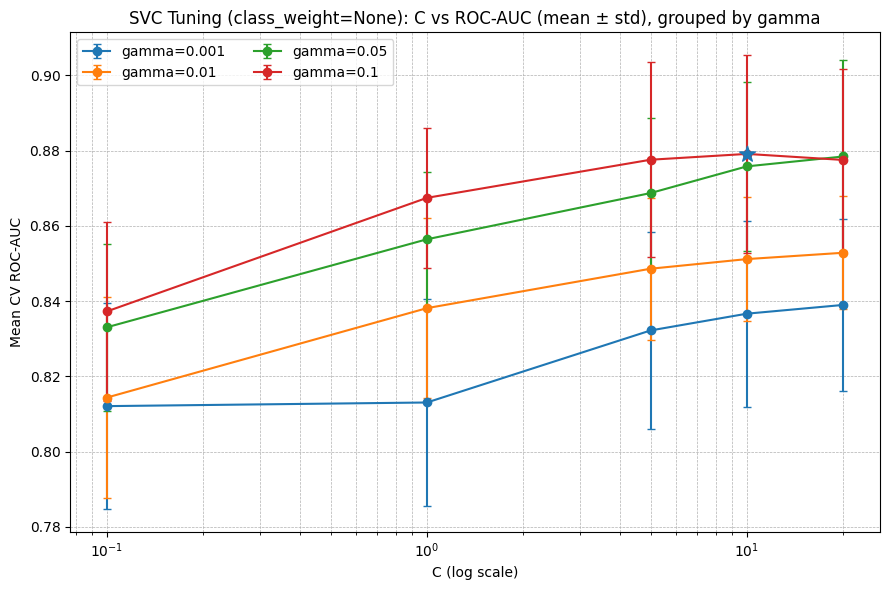

Best point: {'param_clf__C': 10.0, 'param_clf__gamma': 0.1, 'param_clf__class_weight': 'None', 'mean_test_score': 0.8791322323823401, 'std_test_score': 0.026273873957690336, 'rank_test_score': 1}


In [12]:
plt.figure(figsize=(9,6))

for g in sorted(res["param_clf__gamma"].unique()):
    sub = res[(res["param_clf__gamma"] == g) & (res["param_clf__class_weight"] == "None")].sort_values("param_clf__C")
    plt.errorbar(
        sub["param_clf__C"],
        sub["mean_test_score"],
        yerr=sub["std_test_score"],
        marker="o",
        capsize=3,
        label=f"gamma={g:g}"
    )

# 标出最优点
best_idx = res["mean_test_score"].idxmax()
best = res.loc[best_idx]
plt.scatter([best["param_clf__C"]], [best["mean_test_score"]], s=140, marker="*", zorder=5)

plt.xscale("log")
plt.xlabel("C (log scale)")
plt.ylabel("Mean CV ROC-AUC")
plt.title("SVC Tuning (class_weight=None): C vs ROC-AUC (mean ± std), grouped by gamma")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

print("Best point:", dict(best))


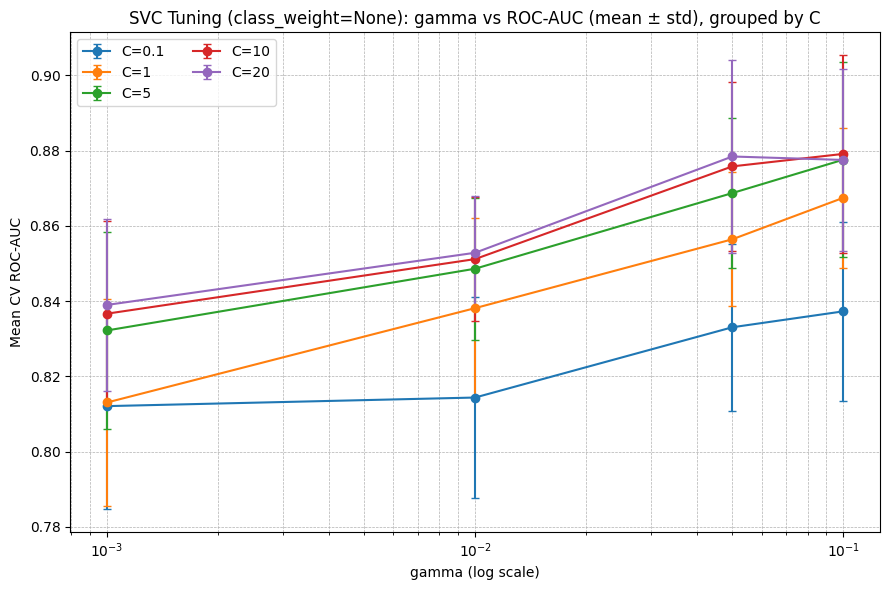

In [13]:
plt.figure(figsize=(9,6))

for C in sorted(res["param_clf__C"].unique()):
    sub = res[(res["param_clf__C"] == C) & (res["param_clf__class_weight"] == "None")].sort_values("param_clf__gamma")
    plt.errorbar(
        sub["param_clf__gamma"],
        sub["mean_test_score"],
        yerr=sub["std_test_score"],
        marker="o",
        capsize=3,
        label=f"C={C:g}"
    )

plt.xscale("log")
plt.xlabel("gamma (log scale)")
plt.ylabel("Mean CV ROC-AUC")
plt.title("SVC Tuning (class_weight=None): gamma vs ROC-AUC (mean ± std), grouped by C")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


In [14]:
# 取前10名（rank=1 表示最好）
top10 = res.sort_values("rank_test_score").head(10)

# 排个更直观的顺序
top10 = top10.sort_values(
    ["rank_test_score", "param_clf__gamma", "param_clf__C"]
)

# 导出为 CSV（论文补充材料/附表用）
top10.to_csv("SVC_gridsearch_top10.csv", index=False)

print("Saved: SVC_gridsearch_top10.csv")

# 在控制台看一眼
print(top10)




Saved: SVC_gridsearch_top10.csv
    param_clf__C  param_clf__gamma param_clf__class_weight  mean_test_score  \
27          10.0              0.10                    None         0.879132   
34          20.0              0.05                    None         0.878446   
19           5.0              0.10                    None         0.877587   
35          20.0              0.10                    None         0.877527   
38          20.0              0.05                balanced         0.877399   
31          10.0              0.10                balanced         0.877228   
23           5.0              0.10                balanced         0.876765   
39          20.0              0.10                balanced         0.876484   
30          10.0              0.05                balanced         0.875994   
26          10.0              0.05                    None         0.875819   

    std_test_score  rank_test_score  
27        0.026274                1  
34        0.025687    

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_validate
from sklearn.metrics import roc_auc_score, classification_report
import numpy as np

# =========================
# Step 1. 训练集上调参
# =========================

pipe = Pipeline([
    ("clf", RandomForestClassifier(
        random_state=2024,
        n_jobs=1
    ))
])

param_grid = {
    "clf__n_estimators": [200, 500],
    "clf__max_depth": [5, 10, 15, None],
    "clf__min_samples_leaf": [1, 5, 10],
    "clf__max_features": ["sqrt", 0.3, 0.5],
    "clf__class_weight": [None, "balanced"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=2024)

grid_rf = GridSearchCV(
    pipe,
    param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=1,
    verbose=1
)

grid_rf.fit(X_train, y_train)

print("Best CV AUC:", grid_rf.best_score_)
print("Best params:", grid_rf.best_params_)

best_rf = grid_rf.best_estimator_


# =========================
# Step 2. 统一评估
# =========================

def eval_model(model, X_train, y_train, X_test, y_test, cv=5):
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=2024)
    scoring = {
        "auc":"roc_auc",
        "acc":"accuracy",
        "precision":"precision",
        "recall":"recall",
        "f1":"f1"
    }

    cv_res = cross_validate(model, X_train, y_train, cv=skf, scoring=scoring, n_jobs=1)

    print("\n=== CV Performance (Train, mean ± std) ===")
    for k in scoring:
        print(f"{cv_res[f'test_{k}'].mean():.4f} ± {cv_res[f'test_{k}'].std():.4f}")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]

    print("\n=== Test Performance ===")
    print("AUC:", roc_auc_score(y_test, y_proba))
    print(classification_report(y_test, y_pred, digits=4))

    return cv_res, y_pred, y_proba


# =========================
# Step 3. 运行
# =========================

eval_model(best_rf, X_train, y_train, X_test, y_test)

Fitting 5 folds for each of 144 candidates, totalling 720 fits


In [248]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

res = pd.DataFrame(grid_rf.cv_results_)[[
    "param_clf__n_estimators",
    "param_clf__max_depth",
    "param_clf__min_samples_leaf",
    "param_clf__max_features",
    "param_clf__class_weight",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].copy()

# 处理类型
res["param_clf__n_estimators"] = res["param_clf__n_estimators"].astype(int)
res["param_clf__min_samples_leaf"] = res["param_clf__min_samples_leaf"].astype(int)
res["param_clf__class_weight"] = res["param_clf__class_weight"].astype(str)   # None -> "None"
res["param_clf__max_depth"] = res["param_clf__max_depth"].astype(str)         # None -> "None"
res["param_clf__max_features"] = res["param_clf__max_features"].astype(str)   # 0.3 -> "0.3"


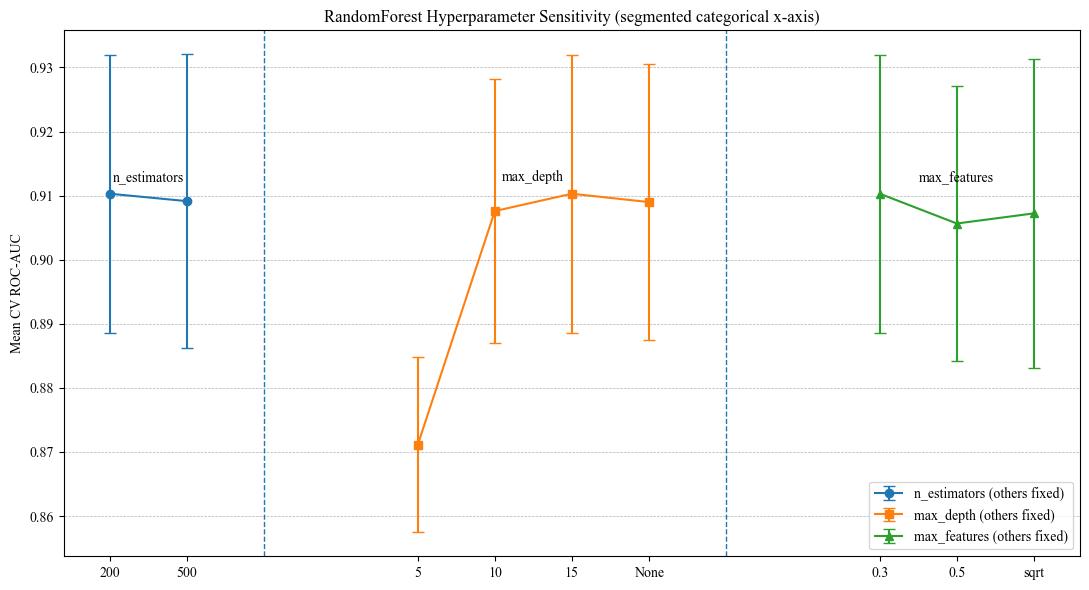

Fixed (best) params used for slicing:
{'n_estimators': 200, 'max_depth': 15, 'min_samples_leaf': 1, 'max_features': 0.3, 'class_weight': 'balanced'}


In [249]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

res = pd.DataFrame(grid_rf.cv_results_).copy()

# 最优组合（rank=1）
best = res.loc[res["rank_test_score"].idxmin()]
best_n    = best["param_clf__n_estimators"]
best_d    = best["param_clf__max_depth"]
best_leaf = best["param_clf__min_samples_leaf"]
best_feat = best["param_clf__max_features"]
best_cw   = best["param_clf__class_weight"]

# ---- 1) n_estimators 曲线（固定其它参数为最优）----
df_n = res[
    (res["param_clf__max_depth"] == best_d) &
    (res["param_clf__min_samples_leaf"] == best_leaf) &
    (res["param_clf__max_features"] == best_feat) &
    (res["param_clf__class_weight"] == best_cw)
].copy()
df_n["val"] = df_n["param_clf__n_estimators"].astype(int)
df_n = df_n.sort_values("val")

# ---- 2) max_depth 曲线（固定其它参数为最优）----
df_d = res[
    (res["param_clf__n_estimators"] == best_n) &
    (res["param_clf__min_samples_leaf"] == best_leaf) &
    (res["param_clf__max_features"] == best_feat) &
    (res["param_clf__class_weight"] == best_cw)
].copy()
# depth=None 也保留为字符串标签，方便显示
df_d["val"] = df_d["param_clf__max_depth"].apply(lambda v: "None" if v is None else str(int(v)))
# 排序：数字在前，None 最后
df_d["sort_key"] = df_d["param_clf__max_depth"].apply(lambda v: 999 if v is None else int(v))
df_d = df_d.sort_values("sort_key")

# ---- 3) max_features 曲线（固定其它参数为最优）----
df_f = res[
    (res["param_clf__n_estimators"] == best_n) &
    (res["param_clf__max_depth"] == best_d) &
    (res["param_clf__min_samples_leaf"] == best_leaf) &
    (res["param_clf__class_weight"] == best_cw)
].copy()
df_f["val"] = df_f["param_clf__max_features"].astype(str)

# 排序：数字在前，sqrt 最后
def feat_sort(v):
    try:
        return float(v)
    except:
        return 999
df_f["sort_key"] = df_f["val"].apply(feat_sort)
df_f = df_f.sort_values("sort_key")

# =========================
# 关键：构造“分段类别轴”
# =========================
gap = 2  # 段与段之间空几个位置
x_n = np.arange(len(df_n))                     # 0,1,...
x_d = np.arange(len(df_d)) + x_n.max() + 1 + gap
x_f = np.arange(len(df_f)) + x_d.max() + 1 + gap

plt.figure(figsize=(11,6))

plt.errorbar(x_n, df_n["mean_test_score"], yerr=df_n["std_test_score"],
             marker="o", capsize=4, label="n_estimators (others fixed)")

plt.errorbar(x_d, df_d["mean_test_score"], yerr=df_d["std_test_score"],
             marker="s", capsize=4, label="max_depth (others fixed)")

plt.errorbar(x_f, df_f["mean_test_score"], yerr=df_f["std_test_score"],
             marker="^", capsize=4, label="max_features (others fixed)")

# x 轴刻度与标签（把真实参数值显示出来）
xticks = np.concatenate([x_n, x_d, x_f])
xlabels = (
    [str(v) for v in df_n["val"].tolist()] +
    [str(v) for v in df_d["val"].tolist()] +
    [str(v) for v in df_f["val"].tolist()]
)

plt.xticks(xticks, xlabels, rotation=0)

# 画分隔线，让三段更清晰
plt.axvline(x=x_n.max() + gap/2, linestyle="--", linewidth=1)
plt.axvline(x=x_d.max() + gap/2, linestyle="--", linewidth=1)

# 段标题（写在图上方）
y_top = max(res["mean_test_score"]) + 0.002
plt.text(x_n.mean(), y_top, "n_estimators", ha="center")
plt.text(x_d.mean(), y_top, "max_depth", ha="center")
plt.text(x_f.mean(), y_top, "max_features", ha="center")

plt.ylabel("Mean CV ROC-AUC")
plt.title("RandomForest Hyperparameter Sensitivity (segmented categorical x-axis)")
plt.grid(True, linestyle="--", linewidth=0.5, axis="y")
plt.legend()
plt.tight_layout()
plt.show()

print("Fixed (best) params used for slicing:")
print({
    "n_estimators": best_n,
    "max_depth": best_d,
    "min_samples_leaf": best_leaf,
    "max_features": best_feat,
    "class_weight": best_cw
})



In [250]:
# Top-10
top10 = res.sort_values("rank_test_score").head(10)
top10.to_csv("RF_gridsearch_top10.csv", index=False)
print("Saved: RF_gridsearch_top10.csv")

# 全量
res.sort_values("rank_test_score").to_csv("RF_gridsearch_results.csv", index=False)
print("Saved: RF_gridsearch_results.csv")


Saved: RF_gridsearch_top10.csv
Saved: RF_gridsearch_results.csv


In [251]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_validate
from sklearn.metrics import roc_auc_score, classification_report
import numpy as np

# =========================
# Step 1. 训练集上调参
# =========================

pipe = Pipeline([
    ("scaler", StandardScaler()),   # KNN 必须标准化
    ("clf", KNeighborsClassifier())
])

param_grid = {
    "clf__n_neighbors": [3, 5, 7, 9, 11, 15],
    "clf__weights": ["uniform", "distance"],
    "clf__metric": ["euclidean", "manhattan"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=2024)

grid_knn = GridSearchCV(
    pipe,
    param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=1,
    verbose=1
)

grid_knn.fit(X_train, y_train)

print("Best CV AUC:", grid_knn.best_score_)
print("Best params:", grid_knn.best_params_)

best_knn = grid_knn.best_estimator_


# =========================
# Step 2. 统一评估
# =========================

def eval_model(model, X_train, y_train, X_test, y_test, cv=5):
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=2024)
    scoring = {
        "auc":"roc_auc",
        "acc":"accuracy",
        "precision":"precision",
        "recall":"recall",
        "f1":"f1"
    }

    cv_res = cross_validate(model, X_train, y_train, cv=skf, scoring=scoring, n_jobs=1)

    print("\n=== CV Performance (Train, mean ± std) ===")
    for k in scoring:
        print(f"{cv_res[f'test_{k}'].mean():.4f} ± {cv_res[f'test_{k}'].std():.4f}")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]

    print("\n=== Test Performance ===")
    print("AUC:", roc_auc_score(y_test, y_proba))
    print(classification_report(y_test, y_pred, digits=4))

    return cv_res, y_pred, y_proba


# =========================
# Step 3. 运行
# =========================

eval_model(best_knn, X_train, y_train, X_test, y_test)


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best CV AUC: 0.8963428306519138
Best params: {'clf__metric': 'manhattan', 'clf__n_neighbors': 15, 'clf__weights': 'distance'}

=== CV Performance (Train, mean ± std) ===
0.8963 ± 0.0300
0.8069 ± 0.0430
0.7478 ± 0.0445
0.8995 ± 0.0279
0.8165 ± 0.0376

=== Test Performance ===
AUC: 0.8883402273032845
              precision    recall  f1-score   support

           0     0.8626    0.7154    0.7821      1114
           1     0.7608    0.8881    0.8195      1135

    accuracy                         0.8026      2249
   macro avg     0.8117    0.8018    0.8008      2249
weighted avg     0.8112    0.8026    0.8010      2249



({'fit_time': array([0.00200534, 0.00199962, 0.00199962, 0.00216389, 0.00197172]),
  'score_time': array([0.00727367, 0.0071826 , 0.00602055, 0.00553441, 0.00821018]),
  'test_auc': array([0.93182307, 0.84136892, 0.91062204, 0.89729083, 0.90060929]),
  'test_acc': array([0.87046632, 0.7357513 , 0.80829016, 0.81770833, 0.80208333]),
  'test_precision': array([0.81308411, 0.67521368, 0.74774775, 0.76415094, 0.73873874]),
  'test_recall': array([0.94565217, 0.85869565, 0.90217391, 0.89010989, 0.9010989 ]),
  'test_f1': array([0.87437186, 0.75598086, 0.81773399, 0.82233503, 0.81188119])},
 array([1, 0, 1, ..., 0, 0, 0], dtype=int64),
 array([0.92939459, 0.34045399, 0.93810584, ..., 0.3362394 , 0.13383505,
        0.        ]))

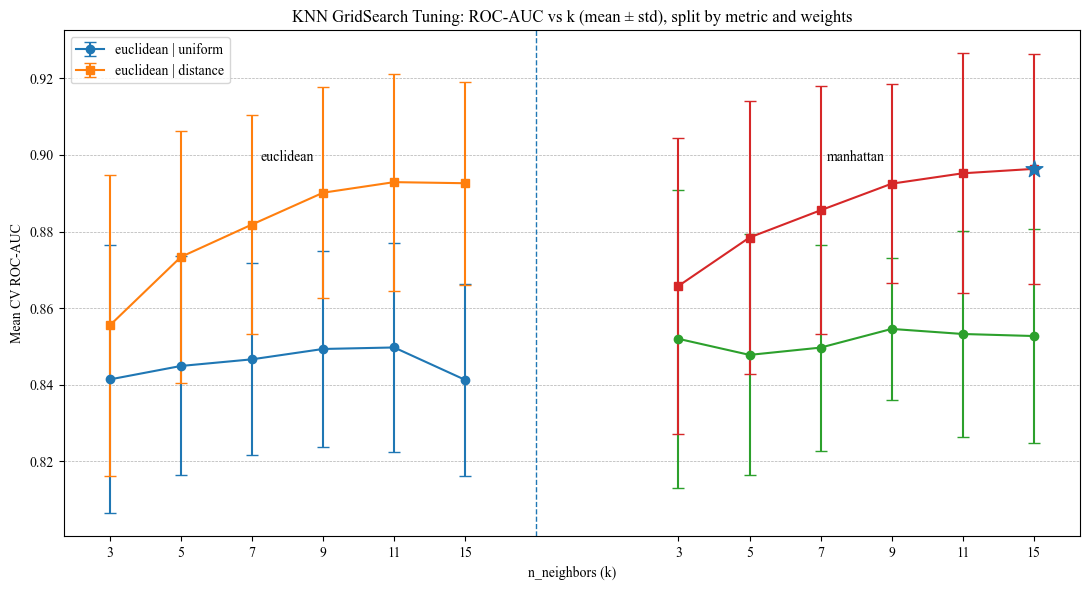

Best point: {'param_clf__n_neighbors': 15, 'param_clf__weights': 'distance', 'param_clf__metric': 'manhattan', 'mean_test_score': 0.8963428306519138, 'std_test_score': 0.030013249638917786, 'rank_test_score': 1}


In [252]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

res = pd.DataFrame(grid_knn.cv_results_)[[
    "param_clf__n_neighbors",
    "param_clf__weights",
    "param_clf__metric",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].copy()

res["param_clf__n_neighbors"] = res["param_clf__n_neighbors"].astype(int)
res["param_clf__weights"] = res["param_clf__weights"].astype(str)
res["param_clf__metric"] = res["param_clf__metric"].astype(str)

# 最优点
best = res.loc[res["rank_test_score"].idxmin()]

# 分段类别轴：先画 euclidean 段，再画 manhattan 段
metrics = ["euclidean", "manhattan"]
gap = 2

plt.figure(figsize=(11,6))

xticks = []
xlabels = []

start = 0
for i, met in enumerate(metrics):
    sub_m = res[res["param_clf__metric"] == met].copy()

    # 该 metric 下的 k 列表（保证顺序）
    ks = sorted(sub_m["param_clf__n_neighbors"].unique().tolist())
    x = np.arange(len(ks)) + start

    # 记录刻度
    xticks.extend(list(x))
    xlabels.extend([str(k) for k in ks])

    # 对不同 weights 画两条线
    for w in ["uniform", "distance"]:
        sub = sub_m[sub_m["param_clf__weights"] == w].set_index("param_clf__n_neighbors").loc[ks].reset_index()
        plt.errorbar(
            x,
            sub["mean_test_score"],
            yerr=sub["std_test_score"],
            marker="o" if w == "uniform" else "s",
            capsize=4,
            label=f"{met} | {w}" if i == 0 else None  # legend 只写一次
        )

    # 标题文字放在段上方
    y_top = res["mean_test_score"].max() + 0.002
    plt.text(x.mean(), y_top, met, ha="center")

    # 画分隔线
    if i == 0:
        plt.axvline(x=x.max() + gap/2, linestyle="--", linewidth=1)

    # 更新下一段起点
    start = x.max() + 1 + gap

# 标出最优点（把它落到对应段的 x 上）
# 计算最优点在分段轴中的 x 位置
def x_pos(metric, k):
    ks = sorted(res[res["param_clf__metric"] == metric]["param_clf__n_neighbors"].unique().tolist())
    idx = ks.index(int(k))
    if metric == "euclidean":
        return idx
    else:
        # euclidean 段长度 + gap + idx
        eu_len = len(sorted(res[res["param_clf__metric"] == "euclidean"]["param_clf__n_neighbors"].unique()))
        return eu_len + gap + idx

best_x = x_pos(best["param_clf__metric"], best["param_clf__n_neighbors"])
plt.scatter([best_x], [best["mean_test_score"]], s=160, marker="*", zorder=5)

plt.xticks(xticks, xlabels)
plt.ylabel("Mean CV ROC-AUC")
plt.xlabel("n_neighbors (k)")
plt.title("KNN GridSearch Tuning: ROC-AUC vs k (mean ± std), split by metric and weights")
plt.grid(True, linestyle="--", linewidth=0.5, axis="y")
plt.legend()
plt.tight_layout()
plt.show()

print("Best point:", dict(best))


In [253]:
import pandas as pd

# 从 GridSearchCV 提取结果
res_knn = pd.DataFrame(grid_knn.cv_results_)

# 只保留最有用的列（可读性更好）
cols = [
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "param_clf__n_neighbors",
    "param_clf__weights",
    "param_clf__metric"
]

res_knn = res_knn[cols].sort_values("rank_test_score")

# ========== Top 10 ==========
top10_knn = res_knn.head(10)
top10_knn.to_csv("KNN_gridsearch_top10.csv", index=False)
print("Saved: KNN_gridsearch_top10.csv")

# ========== 全量 ==========
res_knn.to_csv("KNN_gridsearch_results.csv", index=False)
print("Saved: KNN_gridsearch_results.csv")

# 显示 Top10 方便你核查
print("\n=== KNN Top 10 by CV ROC-AUC ===")
print(top10_knn)


Saved: KNN_gridsearch_top10.csv
Saved: KNN_gridsearch_results.csv

=== KNN Top 10 by CV ROC-AUC ===
    rank_test_score  mean_test_score  std_test_score param_clf__n_neighbors  \
23                1         0.896343        0.030013                     15   
21                2         0.895190        0.031286                     11   
9                 3         0.892884        0.028333                     11   
11                4         0.892598        0.026448                     15   
19                5         0.892478        0.025901                      9   
7                 6         0.890125        0.027536                      9   
17                7         0.885536        0.032362                      7   
5                 8         0.881824        0.028509                      7   
15                9         0.878431        0.035659                      5   
3                10         0.873368        0.032842                      5   

   param_clf__weights param_cl

In [254]:
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_validate
from sklearn.metrics import roc_auc_score, classification_report

# =========================
# Step 1. 训练集上调参
# =========================

xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    random_state=2024,
    n_jobs=1,
    tree_method="hist",   # 更快更稳
)

param_grid = {
    "n_estimators": [300, 600],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 5],
    "reg_lambda": [1, 5],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=2024)

grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=1,
    verbose=1
)

grid_xgb.fit(X_train, y_train)

print("Best CV AUC:", grid_xgb.best_score_)
print("Best params:", grid_xgb.best_params_)

best_xgb = grid_xgb.best_estimator_


# =========================
# Step 2. 统一评估
# =========================

def eval_model(model, X_train, y_train, X_test, y_test, cv=5):
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=2024)
    scoring = {
        "auc":"roc_auc",
        "acc":"accuracy",
        "precision":"precision",
        "recall":"recall",
        "f1":"f1"
    }

    cv_res = cross_validate(model, X_train, y_train, cv=skf, scoring=scoring, n_jobs=1)

    print("\n=== CV Performance (Train, mean ± std) ===")
    for k in scoring:
        print(f"{k}: {cv_res[f'test_{k}'].mean():.4f} ± {cv_res[f'test_{k}'].std():.4f}")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print("\n=== Test Performance ===")
    print("AUC:", roc_auc_score(y_test, y_proba))
    print(classification_report(y_test, y_pred, digits=4))

    return cv_res, y_pred, y_proba


# =========================
# Step 3. 运行
# =========================

eval_model(best_xgb, X_train, y_train, X_test, y_test)


Fitting 5 folds for each of 432 candidates, totalling 2160 fits
Best CV AUC: 0.900069065673887
Best params: {'colsample_bytree': 0.6, 'learning_rate': 0.03, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 300, 'reg_lambda': 1, 'subsample': 1.0}

=== CV Performance (Train, mean ± std) ===
auc: 0.9001 ± 0.0196
acc: 0.8245 ± 0.0265
precision: 0.7805 ± 0.0201
recall: 0.8777 ± 0.0433
f1: 0.8260 ± 0.0277

=== Test Performance ===
AUC: 0.8868754893664138
              precision    recall  f1-score   support

           0     0.8209    0.7774    0.7985      1114
           1     0.7923    0.8335    0.8124      1135

    accuracy                         0.8057      2249
   macro avg     0.8066    0.8054    0.8054      2249
weighted avg     0.8064    0.8057    0.8055      2249



({'fit_time': array([0.0544858 , 0.04963923, 0.05354881, 0.05562997, 0.05232024]),
  'score_time': array([0.00760841, 0.00725865, 0.00851226, 0.01001692, 0.00843692]),
  'test_auc': array([0.9336526 , 0.87381619, 0.8937796 , 0.90550539, 0.89359156]),
  'test_acc': array([0.87046632, 0.79274611, 0.80829016, 0.83333333, 0.81770833]),
  'test_precision': array([0.80733945, 0.74528302, 0.77777778, 0.78640777, 0.78571429]),
  'test_recall': array([0.95652174, 0.85869565, 0.83695652, 0.89010989, 0.84615385]),
  'test_f1': array([0.87562189, 0.7979798 , 0.80628272, 0.83505155, 0.81481481])},
 array([1, 0, 1, ..., 1, 0, 0], dtype=int64),
 array([0.89711344, 0.27478138, 0.9376849 , ..., 0.5249332 , 0.01346735,
        0.008557  ], dtype=float32))

In [255]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

res = pd.DataFrame(grid_xgb.cv_results_)[[
    "param_n_estimators",
    "param_max_depth",
    "param_learning_rate",
    "param_subsample",
    "param_colsample_bytree",
    "param_min_child_weight",
    "param_reg_lambda",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].copy()

# 转成数值，方便排序/画图
for c in ["param_n_estimators","param_max_depth","param_min_child_weight"]:
    res[c] = res[c].astype(int)
for c in ["param_learning_rate","param_subsample","param_colsample_bytree","param_reg_lambda"]:
    res[c] = res[c].astype(float)


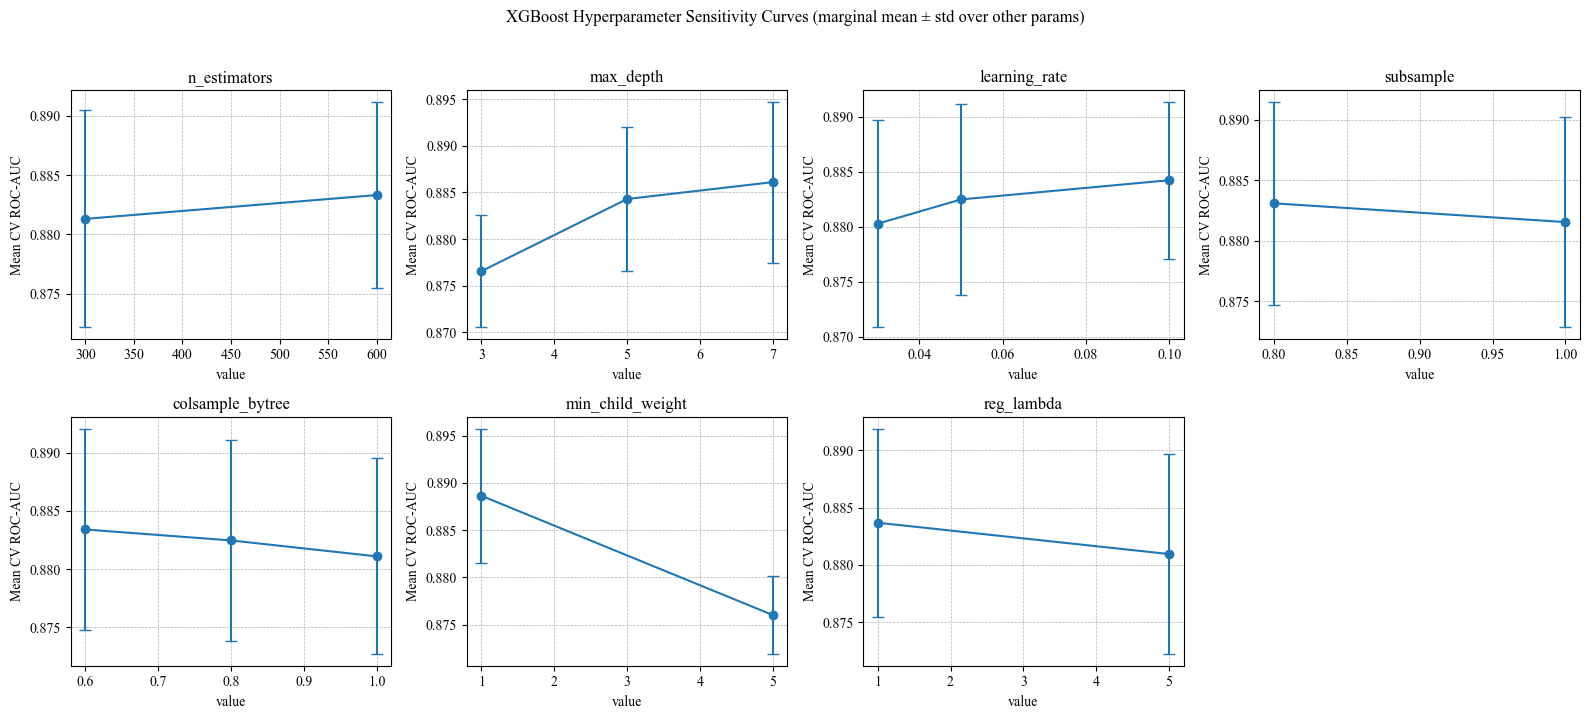

In [256]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1) 提取 GridSearch 结果
cvres = pd.DataFrame(grid_xgb.cv_results_)

params = [
    "param_n_estimators",
    "param_max_depth",
    "param_learning_rate",
    "param_subsample",
    "param_colsample_bytree",
    "param_min_child_weight",
    "param_reg_lambda",
]

# 2) 画“边际曲线”：对每个参数，按该参数分组，对 mean_test_score 做均值±标准差
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, p in enumerate(params):
    ax = axes[i]
    df = cvres[[p, "mean_test_score"]].copy()

    # 转数值方便排序（防止字符串排序错乱）
    df[p] = pd.to_numeric(df[p], errors="coerce")

    g = df.groupby(p)["mean_test_score"].agg(["mean", "std"]).reset_index().sort_values(p)

    ax.errorbar(g[p], g["mean"], yerr=g["std"], marker="o", capsize=4)
    ax.set_title(p.replace("param_", ""))
    ax.set_xlabel("value")
    ax.set_ylabel("Mean CV ROC-AUC")
    ax.grid(True, linestyle="--", linewidth=0.5)

# 多出来的子图删掉
for j in range(len(params), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("XGBoost Hyperparameter Sensitivity Curves (marginal mean ± std over other params)", y=1.02)
plt.tight_layout()
plt.show()



In [257]:
top10 = res.sort_values("rank_test_score").head(10)
top10.to_csv("XGB_gridsearch_top10.csv", index=False)
print("Saved: XGB_gridsearch_top10.csv")

res.sort_values("rank_test_score").to_csv("XGB_gridsearch_results.csv", index=False)
print("Saved: XGB_gridsearch_results.csv")


Saved: XGB_gridsearch_top10.csv
Saved: XGB_gridsearch_results.csv


In [258]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_validate
from sklearn.metrics import roc_auc_score, classification_report

# =========================
# Step 0. 统一评估函数（跟你其他模型完全一致）
# =========================
def eval_model(model, X_train, y_train, X_test, y_test, cv=5):
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=2024)
    scoring = {
        "auc":"roc_auc",
        "acc":"accuracy",
        "precision":"precision",
        "recall":"recall",
        "f1":"f1"
    }

    cv_res = cross_validate(model, X_train, y_train, cv=skf, scoring=scoring, n_jobs=1)

    print("\n=== CV Performance (Train, mean ± std) ===")
    for k in scoring:
        print(f"{k}: {cv_res[f'test_{k}'].mean():.4f} ± {cv_res[f'test_{k}'].std():.4f}")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print("\n=== Test Performance ===")
    print("AUC:", roc_auc_score(y_test, y_proba))
    print(classification_report(y_test, y_pred, digits=4))

    return cv_res, y_pred, y_proba


# =========================
# Step 1. 训练集上调参（AUC 目标）
# =========================
pipe = Pipeline([
    ("scaler", StandardScaler()),  # MLP 必须标准化
    ("clf", MLPClassifier(
        max_iter=800,
        random_state=2024,
        early_stopping=True,       # 防过拟合/更稳
        n_iter_no_change=10
    ))
])

param_grid = {
    "clf__hidden_layer_sizes": [(64,), (128,), (64, 32), (128, 64)],
    "clf__alpha": [1e-5, 1e-4, 1e-3, 1e-2, 1e-1],          # 你原来的0.1会被包含
    "clf__learning_rate_init": [1e-4, 5e-4, 1e-3],
    "clf__activation": ["relu", "tanh"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=2024)

grid_mlp = GridSearchCV(
    pipe,
    param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=1,
    verbose=1
)

grid_mlp.fit(X_train, y_train)

print("Best CV AUC:", grid_mlp.best_score_)
print("Best params:", grid_mlp.best_params_)

best_mlp = grid_mlp.best_estimator_


# =========================
# Step 2. 用最优 MLP 做统一评估（CV + Test）
# =========================
eval_model(best_mlp, X_train, y_train, X_test, y_test, cv=5)


Fitting 5 folds for each of 120 candidates, totalling 600 fits
Best CV AUC: 0.8380499827335817
Best params: {'clf__activation': 'relu', 'clf__alpha': 0.01, 'clf__hidden_layer_sizes': (128,), 'clf__learning_rate_init': 0.001}

=== CV Performance (Train, mean ± std) ===
auc: 0.8380 ± 0.0342
acc: 0.7623 ± 0.0326
precision: 0.7299 ± 0.0235
recall: 0.7928 ± 0.0632
f1: 0.7593 ± 0.0399

=== Test Performance ===
AUC: 0.7643935020049194
              precision    recall  f1-score   support

           0     0.6904    0.7406    0.7146      1114
           1     0.7258    0.6740    0.6989      1135

    accuracy                         0.7070      2249
   macro avg     0.7081    0.7073    0.7068      2249
weighted avg     0.7083    0.7070    0.7067      2249



({'fit_time': array([0.12590933, 0.11154079, 0.06639647, 0.12888336, 0.1128211 ]),
  'score_time': array([0.00325727, 0.00662804, 0.00424385, 0.00400138, 0.00371146]),
  'test_auc': array([0.85702755, 0.83313603, 0.774322  , 0.87188554, 0.85387879]),
  'test_acc': array([0.76683938, 0.75647668, 0.70466321, 0.80208333, 0.78125   ]),
  'test_precision': array([0.74226804, 0.71028037, 0.69662921, 0.76237624, 0.73786408]),
  'test_recall': array([0.7826087 , 0.82608696, 0.67391304, 0.84615385, 0.83516484]),
  'test_f1': array([0.76190476, 0.7638191 , 0.68508287, 0.80208333, 0.78350515])},
 array([1, 0, 1, ..., 0, 0, 0], dtype=int64),
 array([0.56010255, 0.32188661, 0.52081959, ..., 0.33158199, 0.32158683,
        0.49971052]))

In [259]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

res = pd.DataFrame(grid_mlp.cv_results_)[[
    "param_clf__hidden_layer_sizes",
    "param_clf__alpha",
    "param_clf__learning_rate_init",
    "param_clf__activation",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].copy()

res["param_clf__alpha"] = res["param_clf__alpha"].astype(float)
res["param_clf__learning_rate_init"] = res["param_clf__learning_rate_init"].astype(float)
res["param_clf__activation"] = res["param_clf__activation"].astype(str)
res["param_clf__hidden_layer_sizes"] = res["param_clf__hidden_layer_sizes"].astype(str)  # 方便显示


In [260]:
top10 = res.sort_values("rank_test_score").head(10)
top10.to_csv("MLP_gridsearch_top10.csv", index=False)
print("Saved: MLP_gridsearch_top10.csv")

res.sort_values("rank_test_score").to_csv("MLP_gridsearch_results.csv", index=False)
print("Saved: MLP_gridsearch_results.csv")


Saved: MLP_gridsearch_top10.csv
Saved: MLP_gridsearch_results.csv


In [261]:
from sklearn.ensemble import StackingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# =========================
# 1. 定义最优基学习器（全部使用你GridSearch得到的最优参数）
# =========================

base_learners = [

    # Logistic Regression (L1)
    ('lr', Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("clf", LogisticRegression(
            penalty="l1",
            C=0.05,
            class_weight=None,
            solver="saga",
            max_iter=10000,
            random_state=2024
        ))
    ])),

    # SVM (RBF)
    ('svc', Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(
            C=10,
            gamma=0.1,
            class_weight=None,
            probability=True,
            kernel="rbf",
            random_state=2024
        ))
    ])),

    # Random Forest
    ('rf', RandomForestClassifier(
        n_estimators=500,
        max_depth=15,
        min_samples_leaf=1,
        max_features=0.3,
        class_weight="balanced",
        random_state=2024,
        n_jobs=1
    )),

    # KNN
    ('knn', Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(
            n_neighbors=15,
            metric="manhattan",
            weights="distance"
        ))
    ])),

    # XGBoost
    ('xgb', XGBClassifier(
        n_estimators=300,
        max_depth=7,
        learning_rate=0.03,
        subsample=1.0,
        colsample_bytree=0.6,
        min_child_weight=1,
        reg_lambda=1,
        objective="binary:logistic",
        eval_metric="auc",
        random_state=2024,
        n_jobs=1
    )),

    # MLP
    ('mlp', Pipeline([
        ("scaler", StandardScaler()),
        ("clf", MLPClassifier(
            hidden_layer_sizes=(128,),
            alpha=0.01,
            learning_rate_init=0.001,
            activation="relu",
            max_iter=800,
            early_stopping=True,
            n_iter_no_change=10,
            random_state=2024
        ))
    ]))
]

# =========================
# 2. 元学习器（推荐用 LogisticRegression 或 XGB）
# 你当前数据用 LR 更稳；如果你要极限性能可用 XGB
# =========================

meta_learner = RandomForestClassifier(
    n_estimators=1000,
    max_depth=5,               # 元学习器一定要“浅” → 防止过拟合
    min_samples_leaf=10,
    max_features=0.6,
    class_weight="balanced",
    random_state=2024,
    n_jobs=1
)



# =========================
# 3. 构建 Stacking
# =========================

stacking_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    stack_method="predict_proba",   # 用概率作为元特征（医学必须）
    passthrough=False,              # 不把原始特征拼进去（防止信息泄露）
    cv=5,
    n_jobs=1
)

# =========================
# 4. 训练 + 测试
# =========================

stacking_clf.fit(X_train, y_train)

y_pred = stacking_clf.predict(X_test)
y_proba = stacking_clf.predict_proba(X_test)[:,1]

from sklearn.metrics import classification_report, roc_auc_score

print("=== Stacking Test Performance ===")
print("AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred, digits=4))



=== Stacking Test Performance ===
AUC: 0.9004662327288258
              precision    recall  f1-score   support

           0     0.8394    0.7837    0.8106      1114
           1     0.8007    0.8529    0.8259      1135

    accuracy                         0.8186      2249
   macro avg     0.8200    0.8183    0.8183      2249
weighted avg     0.8199    0.8186    0.8183      2249



In [262]:
import joblib

# 保存模型到文件
with open('trained_model.joblib', 'wb') as f:
    joblib.dump(stacking_clf, f)

In [263]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import joblib

# 1. 加载外部验证集
#validation_data = pd.read_csv('G:\11111111111111111\python\中国人\数据\validation_datayyT.csv')
filename = r'G:\11111111111111111\python\中国人\数据\validation_datayySS.csv'
data = pd.read_csv(filename)

# 2. 分离特征和标签
y = data['Metastasis']
display(y)
X = data.drop(columns=['Metastasis'])
display(X)



# 4. 加载已经训练好的模型
model = joblib.load('trained_model.joblib')

# 5. 使用模型进行预测
y_pred = model.predict(X)
y_pred_proba = model.predict_proba(X)[:, 1]  # 如果需要概率值

# 6. 计算验证集上的性能指标
accuracy = accuracy_score(y, y_pred)
f1 = f1_score(y, y_pred)
roc_auc = roc_auc_score(y, y_pred_proba)

print(f'Accuracy: {accuracy}')
print(f'F1 Score: {f1}')
print(f'ROC AUC: {roc_auc}')

0     1
1     0
2     0
3     1
4     0
     ..
75    0
76    0
77    1
78    0
79    0
Name: Metastasis, Length: 80, dtype: int64

,Age,Primary site,Histological type,T Stage,N Stage,Surgery status,Radiation status,Chemotherapy status,Tumor size
0,3,3,0,3,2,0,1,1,1
1,1,5,0,0,0,1,1,0,0
2,2,6,0,0,1,1,1,1,3
3,1,5,0,2,2,0,1,1,0
4,2,6,0,1,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...
75,3,0,0,3,1,1,1,0,1
76,3,0,0,3,0,1,1,0,0
77,0,2,0,2,3,1,1,0,1
78,1,0,2,4,4,1,1,0,0


Accuracy: 0.875
F1 Score: 0.5454545454545455
ROC AUC: 0.8323765786452353


Predicted labels (y_pred):
[1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0
 1 0 0 1 0 0]
Predicted probabilities (y_pred_proba):
[0.55081265 0.02394632 0.02471856 0.71242568 0.05940768 0.05024975
 0.08348703 0.07482225 0.02542292 0.02339734 0.03329099 0.07805844
 0.07677981 0.06575385 0.12003577 0.06507568 0.01714671 0.12973067
 0.10860034 0.00912718 0.03496222 0.03124407 0.12992754 0.72156244
 0.07438146 0.04769355 0.22581899 0.17478427 0.05118086 0.14630722
 0.13273124 0.50446332 0.08289685 0.10726931 0.08974706 0.73481
 0.02759947 0.05801989 0.37314576 0.21801437 0.12215951 0.0240937
 0.05801989 0.17216891 0.0922831  0.16776334 0.07677981 0.06442108
 0.04079635 0.19610203 0.32120595 0.04182058 0.22581899 0.04479251
 0.09400713 0.02344307 0.14820956 0.15558035 0.62822394 0.00926984
 0.08714121 0.02067458 0.08311009 0.85429021 0.09688288 0.25290603
 0.28433882 0.23653856 0.07122935 0.

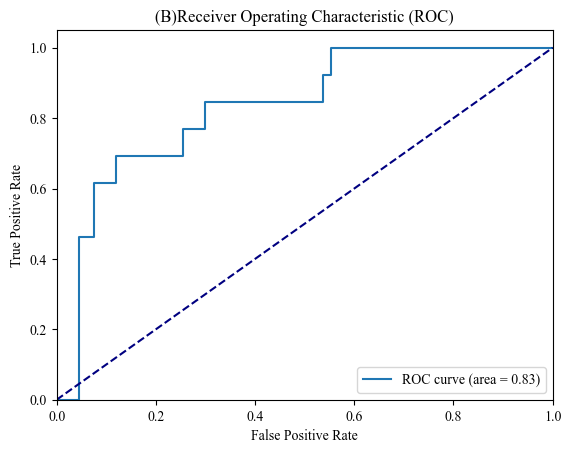

In [264]:
model = stacking_clf

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# 5. 使用模型进行预测
y_pred = model.predict(X)
y_pred_proba = model.predict_proba(X)[:, 1]  # 如果需要概率值

# 输出预测值和概率值
print("Predicted labels (y_pred):")
print(y_pred)

print("Predicted probabilities (y_pred_proba):")
print(y_pred_proba)

# 6. 计算验证集上的性能指标
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# 6. 计算模型性能指标
accuracy = accuracy_score(y, y_pred)
precision = precision_score(y, y_pred)
recall = recall_score(y, y_pred)
f1 = f1_score(y, y_pred)
roc_auc = roc_auc_score(y, y_pred_proba)

# 统一输出（论文友好）
print("Model performance metrics:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")


# 7. 计算并绘制ROC曲线
fpr, tpr, thresholds = roc_curve(y, y_pred_proba)

# 绘制ROC曲线
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')  # 画一条对角线
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('(b)Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()

Confusion Matrix:
[[64  3]
 [ 7  6]]


<Figure size 500x500 with 0 Axes>

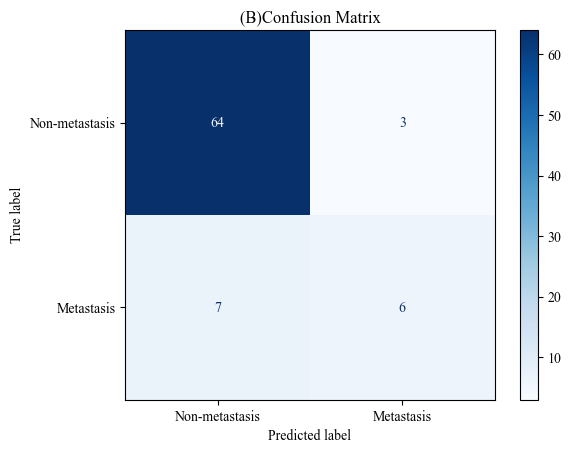

In [265]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 计算混淆矩阵
cm = confusion_matrix(y, y_pred)

print("Confusion Matrix:")
print(cm)

# 可视化混淆矩阵
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-metastasis", "Metastasis"]
)

plt.figure(figsize=(5, 5))
disp.plot(cmap="Blues", values_format="d")
plt.title("(b)Confusion Matrix")
plt.show()


               Feature  Importance
5       Surgery status    0.189240
2    Histological type    0.064384
0                  Age    0.057137
1         Primary site    0.050823
8           Tumor size    0.039084
3              T Stage    0.031214
7  Chemotherapy status    0.030191
4              N Stage    0.029035
6     Radiation status    0.017608


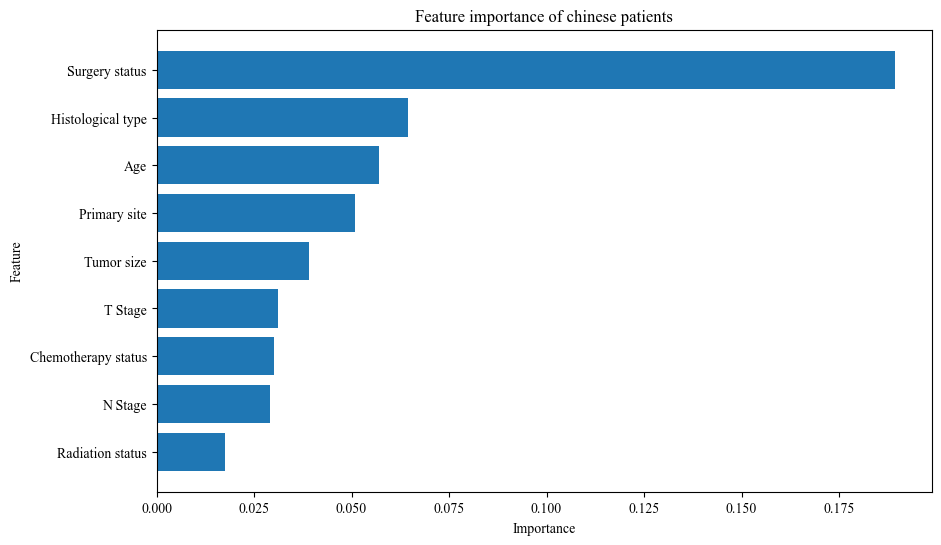

In [266]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

# 假设 X_test 是一个 Pandas DataFrame
feature_names = X_test.columns  # 从 X_test 中提取特征名称

# 计算特征的重要性
result = permutation_importance(stacking_clf, X_test, y_test, n_repeats=10, random_state=2024)
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': result.importances_mean})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# 打印特征重要性数据框
print(importance_df)

# 绘制特征重要性图
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature importance of chinese patients')
plt.gca().invert_yaxis()  # 将最重要的特征放在最上面
plt.show()

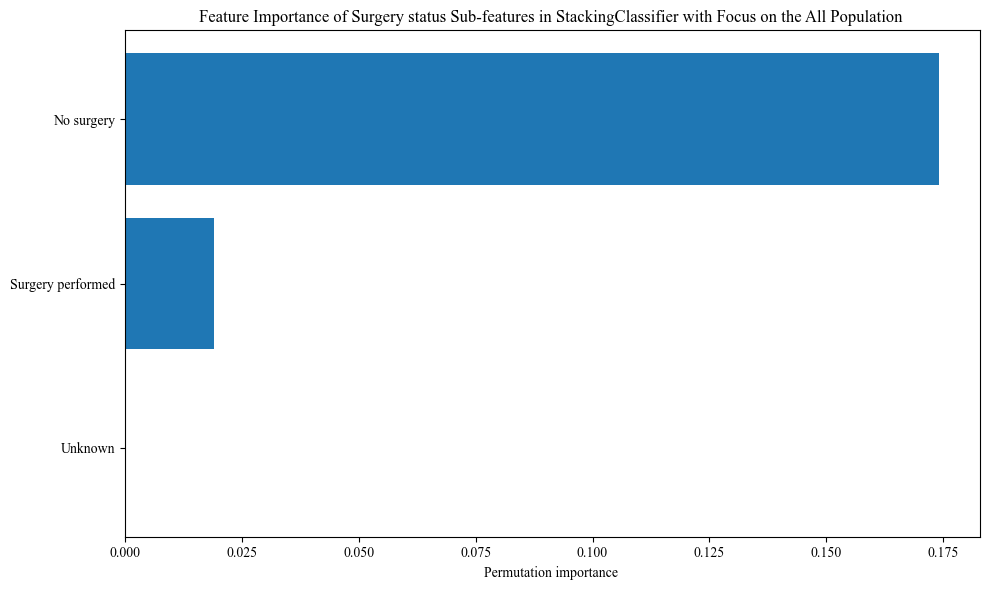

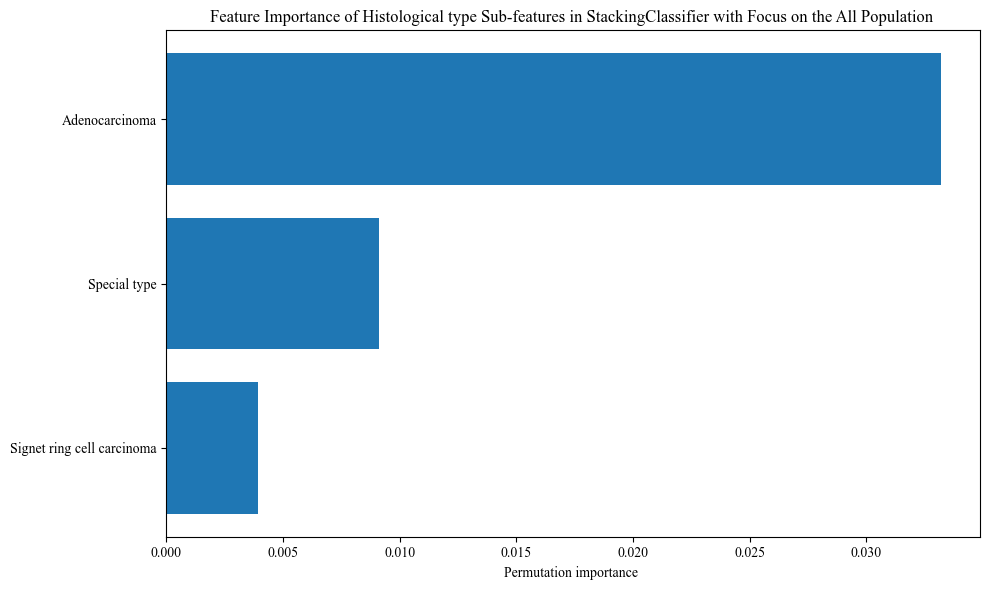

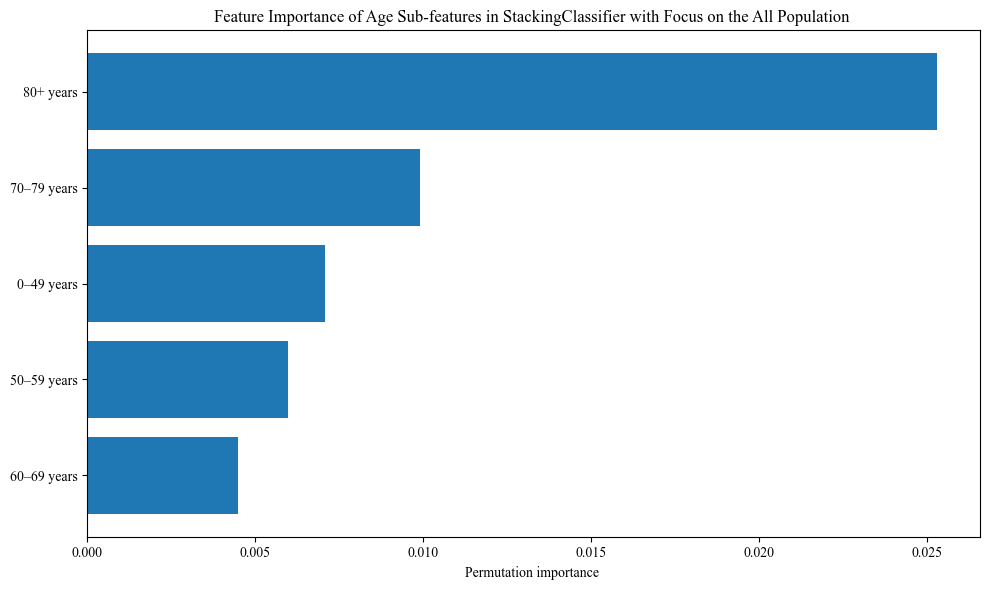

In [267]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

# =========================
# 0) 配置：只处理这三列（Age 无空格）
# =========================
CAT_COLS = ["Surgery status", "Histological type", "Age"]
TOP_N = 10

# 映射字典
surgery_mapping = {
    "Surgery status_0": "No surgery",
    "Surgery status_1": "Surgery performed",
    "Surgery status_2": "Unknown"
}

hist_mapping = {
    "Histological type_0": "Adenocarcinoma",
    "Histological type_1": "Signet ring cell carcinoma",
    "Histological type_2": "Special type"
}

age_mapping = {
    "Age_0": "0–49 years",
    "Age_1": "50–59 years",
    "Age_2": "60–69 years",
    "Age_3": "70–79 years",
    "Age_4": "80+ years"
}

# =========================
# 1) One-hot（只对这三列）
# =========================
X_train_encoded = pd.get_dummies(
    X_train,
    columns=CAT_COLS,
    prefix=CAT_COLS,
    drop_first=False
)

X_test_encoded = pd.get_dummies(
    X_test,
    columns=CAT_COLS,
    prefix=CAT_COLS,
    drop_first=False
)

# 对齐特征
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

# =========================
# 2) 训练 stacking
# =========================
stacking_clf.fit(X_train_encoded, y_train)

# =========================
# 3) permutation importance（用 AUC）
# =========================
result = permutation_importance(
    stacking_clf,
    X_test_encoded,
    y_test,
    n_repeats=10,
    random_state=2024,
    scoring="roc_auc",
    n_jobs=1
)

importance_df = pd.DataFrame({
    "Feature": X_test_encoded.columns,
    "Importance": result.importances_mean
}).sort_values("Importance", ascending=False)

# =========================
# 4) 画分组图函数
# =========================
def plot_group_importance(df, prefix, mapping, title, top_n=10):
    sub = df[df["Feature"].str.startswith(prefix)].copy()
    sub["Feature"] = sub["Feature"].replace(mapping)
    sub = sub.sort_values("Importance", ascending=False).head(top_n)

    plt.figure(figsize=(10, 6))
    plt.barh(sub["Feature"], sub["Importance"])
    plt.xlabel("Permutation importance ")
    plt.title(title)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

# =========================
# 5) 分别画三组
# =========================
plot_group_importance(
    importance_df,
    prefix="Surgery status_",
    mapping=surgery_mapping,
    title="Feature Importance of Surgery status Sub-features in StackingClassifier with Focus on the All Population ",
    top_n=TOP_N
)

plot_group_importance(
    importance_df,
    prefix="Histological type_",
    mapping=hist_mapping,
    title="Feature Importance of Histological type Sub-features in StackingClassifier with Focus on the All Population ",
    top_n=TOP_N
)

plot_group_importance(
    importance_df,
    prefix="Age_",
    mapping=age_mapping,
    title="Feature Importance of Age Sub-features in StackingClassifier with Focus on the All Population ",
    top_n=TOP_N
)



In [268]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

models = {

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("clf", LogisticRegression(
            penalty="l1",
            C=0.05,
            solver="saga",
            max_iter=10000,
            random_state=2024
        ))
    ]),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(
            C=10,
            gamma=0.1,
            kernel="rbf",
            probability=True,
            random_state=2024
        ))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        max_depth=15,
        min_samples_leaf=1,
        max_features=0.3,
        class_weight="balanced",
        random_state=2024
    ),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(
            n_neighbors=15,
            metric="manhattan",
            weights="distance"
        ))
    ]),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=7,
        learning_rate=0.03,
        subsample=1.0,
        colsample_bytree=0.6,
        min_child_weight=1,
        reg_lambda=1,
        objective="binary:logistic",
        eval_metric="auc",
        random_state=2024
    ),

    "MLP": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", MLPClassifier(
            hidden_layer_sizes=(128,),
            alpha=0.01,
            learning_rate_init=0.001,
            activation="relu",
            max_iter=800,
            early_stopping=True,
            random_state=2024
        ))
    ]),

    "Stacking": stacking_clf   # 你刚刚构建并训练的那个 Stacking
}


In [269]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, recall_score, precision_score, accuracy_score, f1_score

# 初始化存储交叉验证的结果
auc_scores = []
recall_scores = []
precision_scores = []
accuracy_scores = []
f1_scores = []

# 5 折交叉验证
cv = StratifiedKFold(n_splits=5)

for train_idx, val_idx in cv.split(X_train, y_train):
    # 获取每一折的训练和验证集
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    # 训练堆叠模型
    stacking_clf.fit(X_fold_train, y_fold_train)
    
    # 获取预测概率和预测标签
    y_proba = stacking_clf.predict_proba(X_fold_val)[:, 1]
    y_pred = stacking_clf.predict(X_fold_val)
    
    # 计算每一折的指标
    auc_scores.append(roc_auc_score(y_fold_val, y_proba))
    recall_scores.append(recall_score(y_fold_val, y_pred))
    precision_scores.append(precision_score(y_fold_val, y_pred))
    accuracy_scores.append(accuracy_score(y_fold_val, y_pred))
    f1_scores.append(f1_score(y_fold_val, y_pred))

# 计算各指标的平均值
mean_auc = np.mean(auc_scores)
mean_recall = np.mean(recall_scores)
mean_precision = np.mean(precision_scores)
mean_accuracy = np.mean(accuracy_scores)
mean_f1 = np.mean(f1_scores)

# 打印平均指标
print(f"10-Fold Cross-Validated AUC: {mean_auc:.4f}")
print(f"10-Fold Cross-Validated Recall: {mean_recall:.4f}")
print(f"10-Fold Cross-Validated Precision: {mean_precision:.4f}")
print(f"10-Fold Cross-Validated Accuracy: {mean_accuracy:.4f}")
print(f"10-Fold Cross-Validated F1 Score: {mean_f1:.4f}")


10-Fold Cross-Validated AUC: 0.9095
10-Fold Cross-Validated Recall: 0.8668
10-Fold Cross-Validated Precision: 0.7786
10-Fold Cross-Validated Accuracy: 0.8182
10-Fold Cross-Validated F1 Score: 0.8192


In [223]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
import numpy as np

def plot_precision_recall(models, X_train, y_train, X_test, y_test, title=None):
    """
    论文级 PR 曲线：
    - 支持 predict_proba / decision_function
    - 带 no-skill baseline（正例比例）
    - 图例按 AP 从高到低排序
    """
    plt.figure(figsize=(10, 8))

    curves = []   # 用来存 (AP, name, recall, precision)

    # =========================
    # 1) 计算每个模型的 PR 曲线与 AP
    # =========================
    for name, model in models.items():
        model.fit(X_train, y_train)

        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(X_test)[:, 1]
        elif hasattr(model, "decision_function"):
            y_score = model.decision_function(X_test)
        else:
            print(f"[Skip] {name}: no probability output")
            continue

        precision, recall, _ = precision_recall_curve(y_test, y_score)
        ap = average_precision_score(y_test, y_score)

        curves.append((ap, name, recall, precision))

    # =========================
    # 2) 按 AP 从高到低排序
    # =========================
    curves = sorted(curves, key=lambda x: x[0], reverse=True)

    # =========================
    # 3) 画每条曲线
    # =========================
    for ap, name, recall, precision in curves:
        plt.plot(recall, precision, lw=2, label=f"{name} (AP={ap:.3f})")

    # =========================
    # 4) No-skill baseline（正例比例）
    # =========================
    positive_rate = np.mean(y_test)
    plt.hlines(
        positive_rate, 
        xmin=0, xmax=1, 
        colors="gray", linestyles="--",
        label=f"No-skill (Pos rate = {positive_rate:.3f})"
    )

    # =========================
    # 5) 坐标轴 & 标题
    # =========================
    plt.xlabel("Recall", fontsize=14)
    plt.ylabel("Precision", fontsize=14)
    plt.title(title if title else "Precision–Recall Curves", fontsize=16)

    # =========================
    # 6) 样式
    # =========================
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend(loc="lower left", fontsize=11, frameon=False)
    plt.tight_layout()
    plt.show()


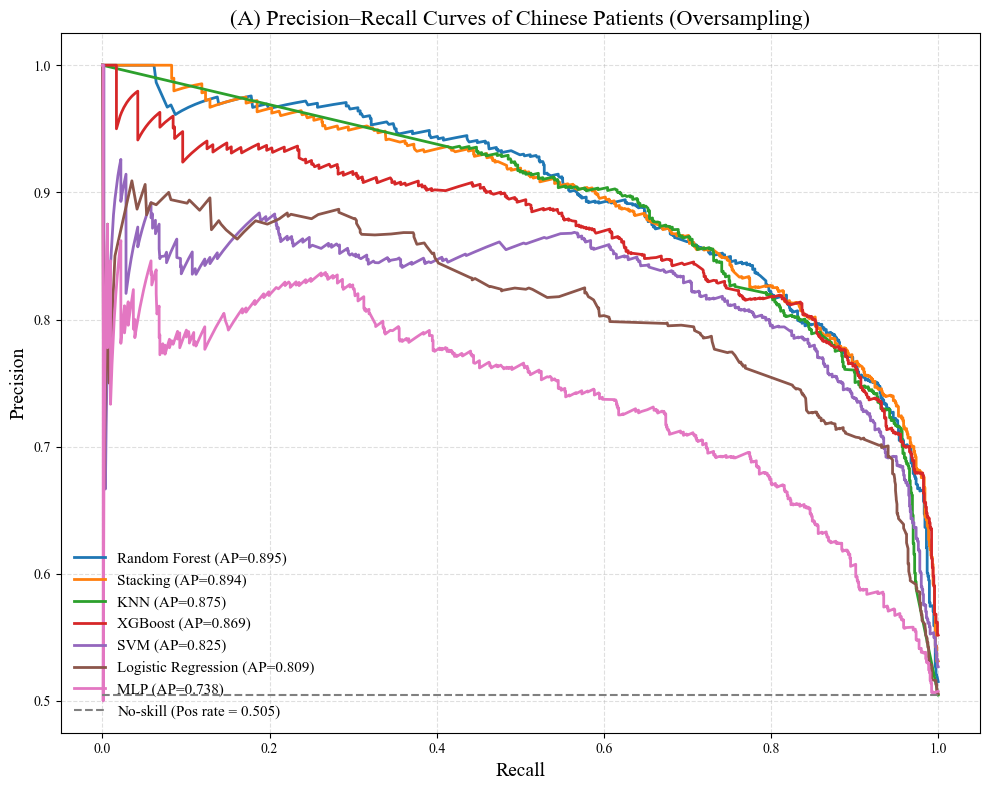

In [224]:
plot_precision_recall(
    models,
    X_train, y_train,
    X_test, y_test,
    title="(a) Precision–Recall Curves of Chinese Patients (Oversampling)"
)


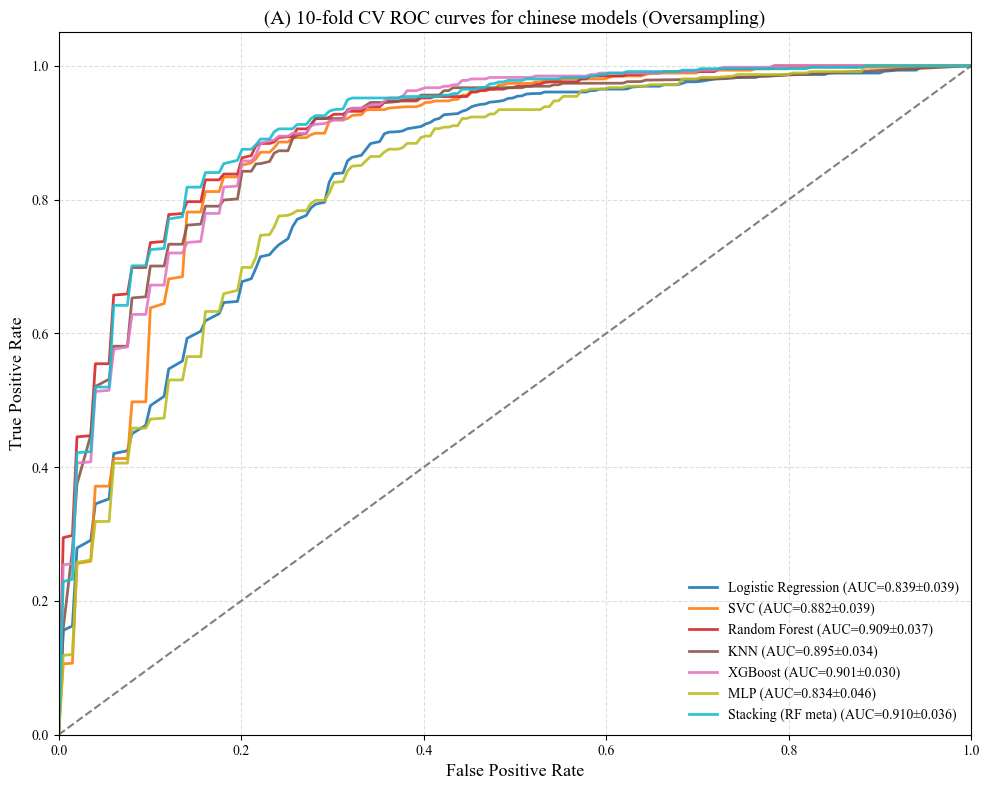

In [225]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

import matplotlib.cm as cm

# 字体（可选）
plt.rc('font', family='Times New Roman')

RANDOM_STATE = 2024

# =========================
# 1) 定义“调好的最佳参数”单模型
# =========================
lr_best = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("clf", LogisticRegression(
        penalty="l1",
        C=0.05,
        class_weight=None,
        solver="saga",
        max_iter=10000,
        random_state=RANDOM_STATE
    ))
])

svc_best = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(
        C=10,
        gamma=0.1,
        class_weight=None,
        probability=True,
        kernel="rbf",
        random_state=RANDOM_STATE
    ))
])

rf_best = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    min_samples_leaf=1,
    max_features=0.3,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=1
)

knn_best = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", KNeighborsClassifier(
        n_neighbors=15,
        metric="manhattan",
        weights="distance"
    ))
])

xgb_best = XGBClassifier(
    n_estimators=300,
    max_depth=7,
    learning_rate=0.03,
    subsample=1.0,
    colsample_bytree=0.6,
    min_child_weight=1,
    reg_lambda=1,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=RANDOM_STATE,
    n_jobs=1,
    tree_method="hist"
)

mlp_best = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", MLPClassifier(
        hidden_layer_sizes=(128,),
        alpha=0.01,
        learning_rate_init=0.001,
        activation="relu",
        max_iter=800,
        early_stopping=True,
        n_iter_no_change=10,
        random_state=RANDOM_STATE
    ))
])

# =========================
# 2) 定义 Stacking（基学习器用最优模型；元学习器用 RF）
#    注意：stack_method="predict_proba"
# =========================
base_learners = [
    ("lr", lr_best),
    ("svc", svc_best),
    ("rf", rf_best),
    ("knn", knn_best),
    ("xgb", xgb_best),
    ("mlp", mlp_best),
]

meta_learner = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    min_samples_leaf=10,
    max_features=0.6,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=1
)

stacking_best = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    stack_method="predict_proba",
    passthrough=False,
    cv=5,
    n_jobs=1
)

# =========================
# 3) 模型字典（包含 stacking）
# =========================
models = {
    "Logistic Regression": lr_best,
    "SVC": svc_best,
    "Random Forest": rf_best,
    "KNN": knn_best,
    "XGBoost": xgb_best,
    "MLP": mlp_best,
    "Stacking (RF meta)": stacking_best
}

# =========================
# 4) 10 折分层 CV 画均值 ROC
# =========================
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

plt.figure(figsize=(10, 8))
color_map = cm.get_cmap('tab10', len(models))
mean_fpr = np.linspace(0, 1, 200)

for i, (model_name, model) in enumerate(models.items()):
    tprs = []
    aucs = []

    for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
        X_fold_train = X_train.iloc[train_idx]
        y_fold_train = y_train.iloc[train_idx]
        X_fold_val   = X_train.iloc[val_idx]
        y_fold_val   = y_train.iloc[val_idx]

        # 每折单独 fit（避免泄漏）
        model.fit(X_fold_train, y_fold_train)

        # 取连续分数：优先 proba，其次 decision_function
        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(X_fold_val)[:, 1]
        elif hasattr(model, "decision_function"):
            y_score = model.decision_function(X_fold_val)
        else:
            raise ValueError(f"{model_name} has no predict_proba/decision_function")

        fpr, tpr, _ = roc_curve(y_fold_val, y_score)
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)

        tpr_interp = np.interp(mean_fpr, fpr, tpr)
        tpr_interp[0] = 0.0
        tprs.append(tpr_interp)

    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(mean_fpr, mean_tpr)
    std_auc = np.std(aucs)

    plt.plot(
        mean_fpr, mean_tpr,
        label=f"{model_name} (AUC={mean_auc:.3f}±{std_auc:.3f})",
        color=color_map(i % color_map.N),
        lw=2,
        alpha=0.9
    )

# 对角线
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", lw=1.5)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate", fontsize=13)
plt.ylabel("True Positive Rate", fontsize=13)
plt.title("(a) 10-fold CV ROC curves for chinese models (Oversampling)", fontsize=14)

plt.legend(loc="lower right", fontsize=10, frameon=False)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


In [226]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

plt.rc('font', family='Times New Roman')

def get_DCA_coords(y_proba, y_true, pt_arr=None, epsilon=1e-10):
    """
    DCA: Net benefit = TP/n - FP/n * pt/(1-pt)
    """
    if pt_arr is None:
        pt_arr = np.linspace(0.01, 0.99, 200)  # 避免0/1
    net_bnf_arr = []

    y_true = np.asarray(y_true)

    for pt in pt_arr:
        tp = ((y_proba >= pt) & (y_true == 1)).sum()
        fp = ((y_proba >= pt) & (y_true == 0)).sum()
        n = len(y_true)

        net_benefit = tp / n - (fp / n) * (pt / (1 - pt + epsilon))
        net_bnf_arr.append(net_benefit)

    return pt_arr, np.array(net_bnf_arr)

def plot_multiclfs_DCA(clfs, X_train, y_train, X_test, y_true,
                       pt_min=0.01, pt_max=0.99, n_pts=200, fn=None):
    """
    clfs: list of (name, estimator)
    """
    # 1) 训练
    for _, clf in clfs:
        clf.fit(X_train, y_train)

    y_true = np.asarray(y_true)
    pi = y_true.mean()  # prevalence

    # 2) 阈值
    pt_arr = np.linspace(pt_min, pt_max, n_pts)

    # 3) 作图
    plt.figure(figsize=(10, 8), dpi=120)
    color_map = cm.get_cmap('tab10', len(clfs))

    for i, (name, clf) in enumerate(clfs):
        # 获取概率
        if hasattr(clf, "predict_proba"):
            y_proba = clf.predict_proba(X_test)[:, 1]
        elif hasattr(clf, "decision_function"):
            # 不推荐：这里只做兜底（SVC若不开probability才会走到这里）
            scores = clf.decision_function(X_test)
            y_proba = (scores - scores.min()) / (scores.max() - scores.min() + 1e-12)
        else:
            print(f"[Skip] {name}: no predict_proba/decision_function")
            continue

        _, net_bnf = get_DCA_coords(y_proba, y_true, pt_arr=pt_arr)
        plt.plot(pt_arr, net_bnf, lw=2, color=color_map(i), label=name, alpha=0.9)

    # 4) All-negative / All-positive
    plt.plot(pt_arr, np.zeros_like(pt_arr), color="black", lw=1.5, linestyle="--", label="Treat None")

    # Treat All: pi - (1-pi)*pt/(1-pt)
    all_pos = pi - (1 - pi) * pt_arr / (1 - pt_arr + 1e-10)
    plt.plot(pt_arr, all_pos, color="gray", lw=1.5, linestyle=":", label="Treat All")

    # 5) 美化
    plt.xlim([pt_min, pt_max])
    plt.ylim([-0.1, max(0.2, np.nanmax(all_pos) + 0.05)])
    plt.xlabel("Threshold probability", fontsize=13)
    plt.ylabel("Net benefit", fontsize=13)
    plt.title("(a) Decision Curve Analysis (DCA) for chinese patients (Oversampling)", fontsize=14)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend(loc="best", frameon=False, fontsize=10)
    plt.tight_layout()

    if fn:
        plt.savefig(fn, dpi=300, bbox_inches="tight")

    plt.show()





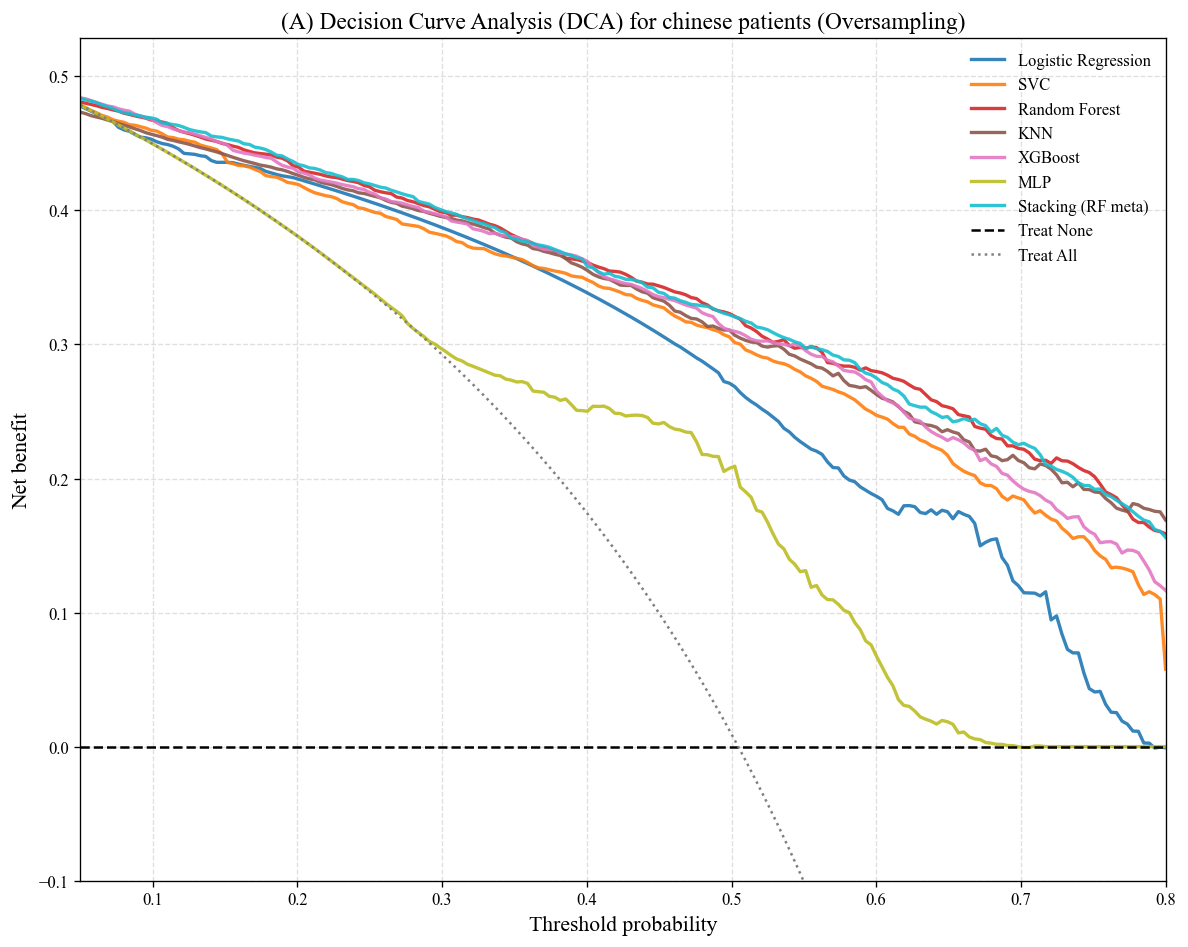

In [227]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

RANDOM_STATE = 2024

# 单模型（最佳参数）
lr_best = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("clf", LogisticRegression(
        penalty="l1", C=0.05, solver="saga",
        max_iter=10000, random_state=RANDOM_STATE
    ))
])

svc_best = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(
        C=10, gamma=0.1, kernel="rbf",
        probability=True, random_state=RANDOM_STATE
    ))
])

rf_best = RandomForestClassifier(
    n_estimators=500, max_depth=15, min_samples_leaf=1,
    max_features=0.3, class_weight="balanced",
    random_state=RANDOM_STATE, n_jobs=1
)

knn_best = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", KNeighborsClassifier(
        n_neighbors=15, metric="manhattan", weights="distance"
    ))
])

xgb_best = XGBClassifier(
    n_estimators=300, max_depth=7, learning_rate=0.03,
    subsample=1.0, colsample_bytree=0.6,
    min_child_weight=1, reg_lambda=1,
    objective="binary:logistic", eval_metric="auc",
    random_state=RANDOM_STATE, n_jobs=1, tree_method="hist"
)

mlp_best = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", MLPClassifier(
        hidden_layer_sizes=(128,),
        alpha=0.01,
        learning_rate_init=0.001,
        activation="relu",
        max_iter=800,
        early_stopping=True,
        n_iter_no_change=10,
        random_state=RANDOM_STATE
    ))
])

# Stacking（最佳基学习器 + RF 元学习器）
base_learners = [
    ("lr", lr_best),
    ("svc", svc_best),
    ("rf", rf_best),
    ("knn", knn_best),
    ("xgb", xgb_best),
    ("mlp", mlp_best),
]

meta_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    min_samples_leaf=10,
    max_features=0.6,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=1
)

stacking_best = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_rf,
    stack_method="predict_proba",
    passthrough=False,
    cv=5,
    n_jobs=1
)

# DCA 用的模型列表
clfs = [
    ("Logistic Regression", lr_best),
    ("SVC", svc_best),
    ("Random Forest", rf_best),
    ("KNN", knn_best),
    ("XGBoost", xgb_best),
    ("MLP", mlp_best),
    ("Stacking (RF meta)", stacking_best),
]

# 画 DCA（阈值建议 0.05~0.80 更贴近临床决策区间）
plot_multiclfs_DCA(
    clfs,
    X_train, y_train,
    X_test, y_test,
    pt_min=0.05, pt_max=0.80, n_pts=200
)


               Feature  Importance
5       Surgery status    0.189240
2    Histological type    0.064384
0                  Age    0.057137
1         Primary site    0.050823
8           Tumor size    0.039084
3              T Stage    0.031214
7  Chemotherapy status    0.030191
4              N Stage    0.029035
6     Radiation status    0.017608


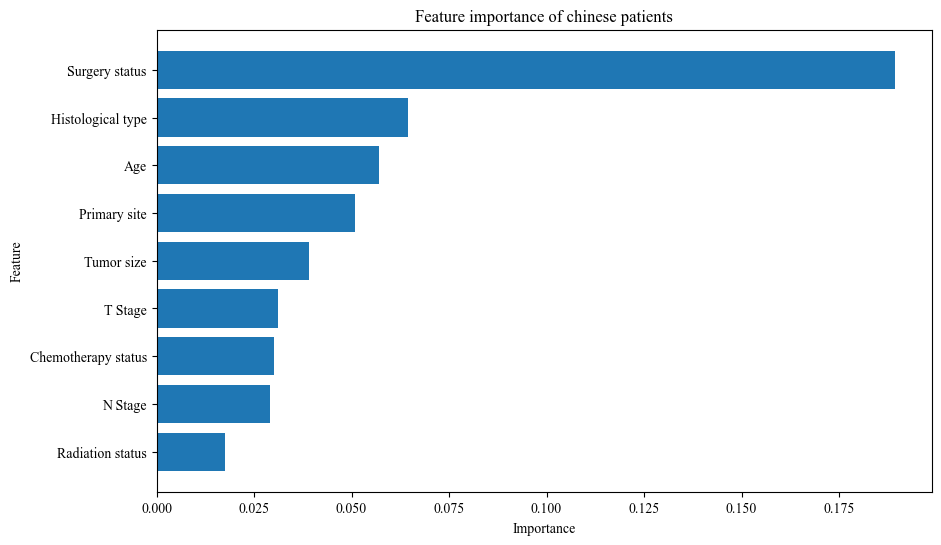

In [228]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

# 假设 X_test 是一个 Pandas DataFrame
feature_names = X_test.columns  # 从 X_test 中提取特征名称

# 计算特征的重要性
result = permutation_importance(stacking_clf, X_test, y_test, n_repeats=10, random_state=2024)
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': result.importances_mean})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# 打印特征重要性数据框
print(importance_df)

# 绘制特征重要性图
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature importance of chinese patients')
plt.gca().invert_yaxis()  # 将最重要的特征放在最上面
plt.show()



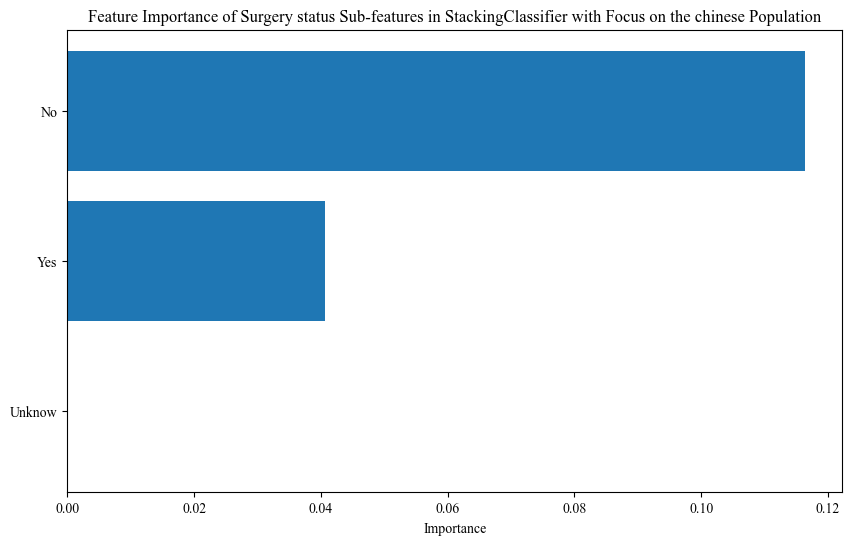

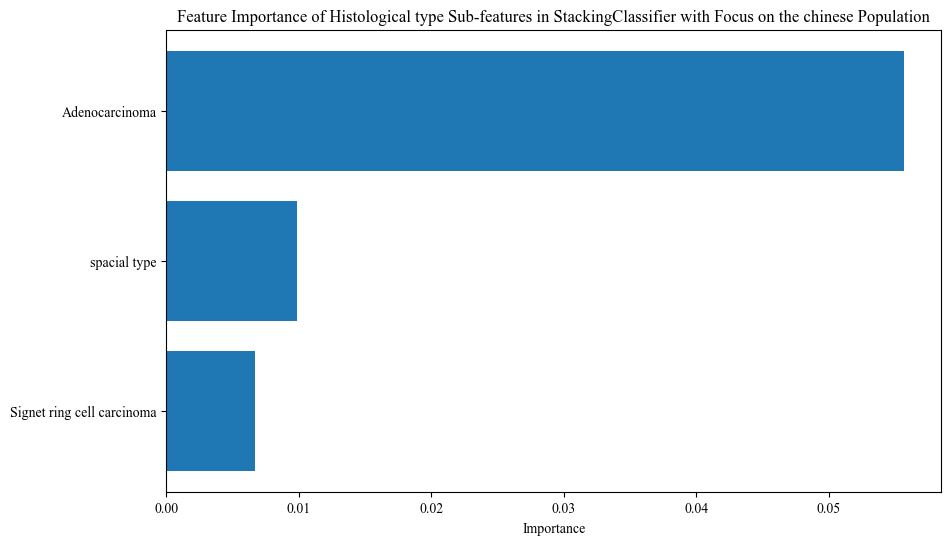

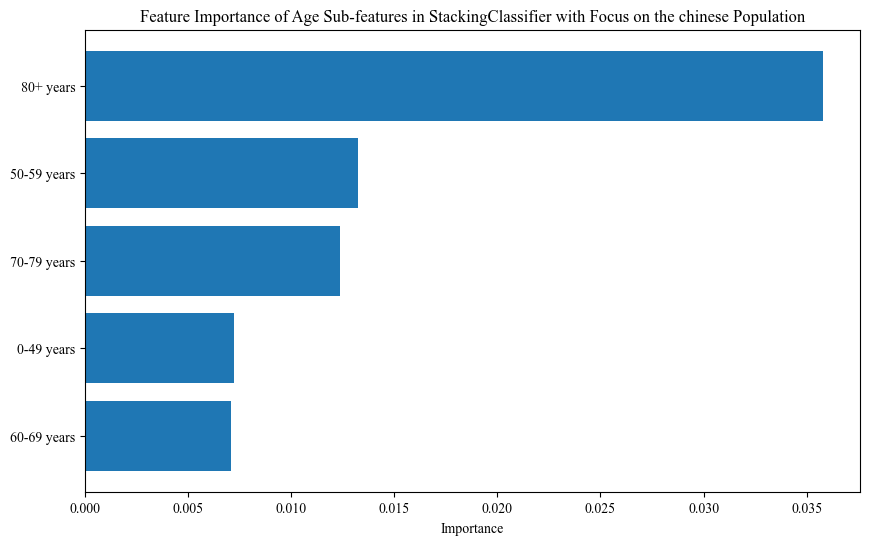

In [229]:
import pandas as pd
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# 对训练集和测试集进行相同的独热编码
X_train_encoded = pd.get_dummies(X_train, columns=['Surgery status', 'Histological type', 'Age'], prefix=['Surgery status', 'Histological type', 'Age'])
X_test_encoded = pd.get_dummies(X_test, columns=['Surgery status', 'Histological type', 'Age'], prefix=['Surgery status', 'Histological type', 'Age'])

# 确保训练和测试集的特征一致（如果特征数量不同，使用 reindex 对齐）
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

# 重新训练 StackingClassifier
stacking_clf.fit(X_train_encoded, y_train)

# 计算 permutation importance
result = permutation_importance(stacking_clf, X_test_encoded, y_test, n_repeats=10, random_state=2024)
importance_df = pd.DataFrame({'Feature': X_test_encoded.columns, 'Importance': result.importances_mean})

# 创建 Surgery status 子特征名称映射字典
primary_site_mapping = {
    "Surgery status_0": "No",
    "Surgery status_1": "Yes",
    "Surgery status_2": "Unknow"
}

# 创建 Histological type 子特征名称映射字典
age_mapping = {
    "Histological type_0": "Adenocarcinoma",
    "Histological type_1": "Signet ring cell carcinoma",
    "Histological type_2": "spacial type"
}

# 创建 Age 子特征名称映射字典
surgery_mapping = {
    "Age_0": "0-49 years",
    "Age_1": "50-59 years",
    "Age_2": "60-69 years",
    "Age_3": "70-79 years",
    "Age_4": "80+ years"
}

# 替换 Surgery status 子特征名称
primary_site_importance_df = importance_df[importance_df['Feature'].str.contains('Surgery status')].sort_values(by='Importance', ascending=False)
primary_site_importance_df['Feature'] = primary_site_importance_df['Feature'].replace(primary_site_mapping)

# 替换 Histological type 子特征名称
age_importance_df = importance_df[importance_df['Feature'].str.contains('Histological type')].sort_values(by='Importance', ascending=False)
age_importance_df['Feature'] = age_importance_df['Feature'].replace(age_mapping)

# 替换 Surgery status 子特征名称
surgery_importance_df = importance_df[importance_df['Feature'].str.contains('Age')].sort_values(by='Importance', ascending=False)
surgery_importance_df['Feature'] = surgery_importance_df['Feature'].replace(surgery_mapping)

# 绘制 Primary Site 子特征的重要性图
plt.figure(figsize=(10, 6))
plt.barh(primary_site_importance_df['Feature'], primary_site_importance_df['Importance'])
plt.xlabel("Importance")
plt.title("Feature Importance of Surgery status Sub-features in StackingClassifier with Focus on the chinese Population")
plt.gca().invert_yaxis()
plt.show()

# 绘制 Age 子特征的重要性图
plt.figure(figsize=(10, 6))
plt.barh(age_importance_df['Feature'], age_importance_df['Importance'])
plt.xlabel("Importance")
plt.title("Feature Importance of Histological type Sub-features in StackingClassifier with Focus on the chinese Population")
plt.gca().invert_yaxis()
plt.show()

# 绘制 Surgery Status 子特征的重要性图
plt.figure(figsize=(10, 6))
plt.barh(surgery_importance_df['Feature'], surgery_importance_df['Importance'])
plt.xlabel("Importance")
plt.title("Feature Importance of Age Sub-features in StackingClassifier with Focus on the chinese Population")
plt.gca().invert_yaxis()
plt.show()



In [230]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import CategoricalNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# 定义基学习器
base_learners = [
    ('lr', LogisticRegression(max_iter=10000, random_state=2024)),
    ('svc', SVC(probability=True, random_state=2024)),
    ('rfc', RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=5, min_samples_split=10, random_state=2024)),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('dtc', DecisionTreeClassifier(random_state=2024)),
    ('mlp', MLPClassifier(alpha=0.1, max_iter=1000, random_state=2024))
]

# 定义元学习器（Logistic Regression）
meta_learner = LogisticRegression(max_iter=10000, random_state=2024)

# 使用堆叠法进行集成
stacking_clf = StackingClassifier(estimators=base_learners, final_estimator=meta_learner)

# 训练堆叠模型
stacking_clf.fit(X_train, y_train)

# 测试集预测
y_pred = stacking_clf.predict(X_test)

e:\anacondabt\envs\py37\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:696: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  ConvergenceWarning,
e:\anacondabt\envs\py37\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:696: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  ConvergenceWarning,


In [231]:
import joblib

# 保存模型到文件
with open('trained_model.joblib', 'wb') as f:
    joblib.dump(stacking_clf, f)

In [232]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import joblib

# 1. 加载外部验证集
#validation_data = pd.read_csv('C:\Users\Administrator\Documents\胃癌肝转移2.0\data\validation_data.csv')
filename = r'C:\Users\Administrator\Documents\胃癌肝转移2.0\data\validation_data.csv'
data = pd.read_csv(filename)

# 2. 分离特征和标签
y = data['Liver metastases']
display(y)
X = data.drop(columns=['Liver metastases'])
display(X)



# 4. 加载已经训练好的模型
model = joblib.load('trained_model.joblib')

# 5. 使用模型进行预测
y_pred = model.predict(X)
y_pred_proba = model.predict_proba(X)[:, 1]  # 如果需要概率值

# 6. 计算验证集上的性能指标
accuracy = accuracy_score(y, y_pred)
f1 = f1_score(y, y_pred)
roc_auc = roc_auc_score(y, y_pred_proba)

print(f'Accuracy: {accuracy}')
print(f'F1 Score: {f1}')
print(f'ROC AUC: {roc_auc}')



FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Administrator\\Documents\\胃癌肝转移2.0\\data\\validation_data.csv'

Predicted labels (y_pred):
[1 1 1 0 0 0 0 0 0 0]
Predicted probabilities (y_pred_proba):
[0.75244369 0.69770404 0.76808358 0.00745155 0.10505845 0.0880066
 0.08325796 0.0797829  0.02735533 0.01280338]
Accuracy: 1.0
F1 Score: 1.0
ROC AUC: 1.0


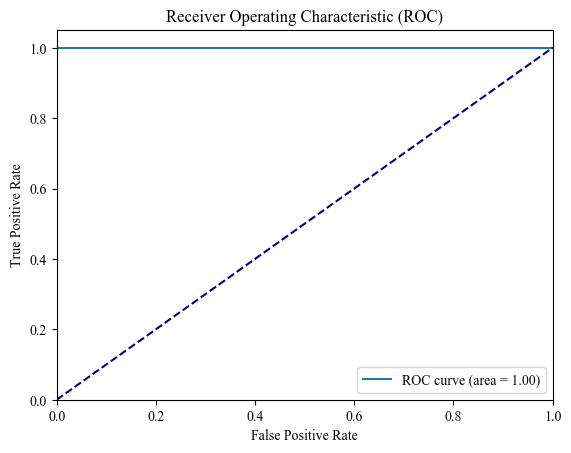

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# 5. 使用模型进行预测
y_pred = model.predict(X)
y_pred_proba = model.predict_proba(X)[:, 1]  # 如果需要概率值

# 输出预测值和概率值
print("Predicted labels (y_pred):")
print(y_pred)

print("Predicted probabilities (y_pred_proba):")
print(y_pred_proba)

# 6. 计算验证集上的性能指标
accuracy = accuracy_score(y, y_pred)
f1 = f1_score(y, y_pred)
roc_auc = roc_auc_score(y, y_pred_proba)

print(f'Accuracy: {accuracy}')
print(f'F1 Score: {f1}')
print(f'ROC AUC: {roc_auc}')

# 7. 计算并绘制ROC曲线
fpr, tpr, thresholds = roc_curve(y, y_pred_proba)

# 绘制ROC曲线
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')  # 画一条对角线
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()



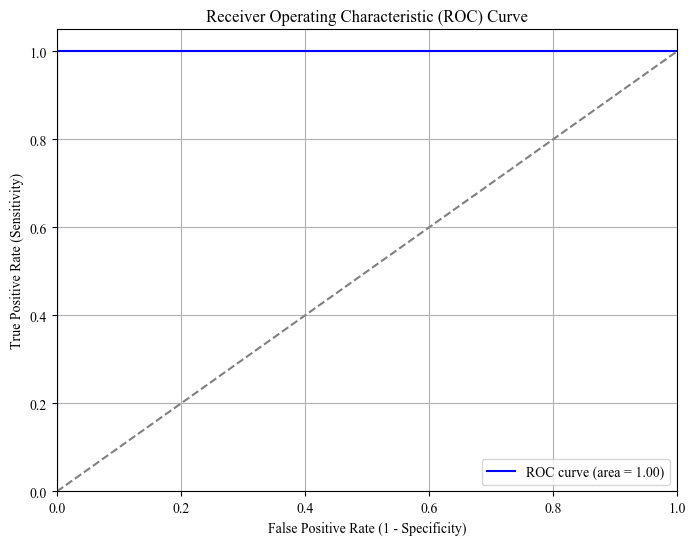

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, confusion_matrix, ConfusionMatrixDisplay

# 绘制 ROC 曲线
fpr, tpr, thresholds = roc_curve(y, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
